In [13]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import warnings

warnings.filterwarnings("ignore", message="Corrupt EXIF data")


In [ ]:
# Define the root directory containing all plant disease datasets

DATASET_DIR = Path("../../data/plant")


In [ ]:
# Define the image file extensions supported by the dataset

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}

# search all subdirectories for image files

image_files = [
    path for path in DATASET_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total image files found:", len(image_files))

Total image files found: 113661


In [ ]:
# Count the number of images belonging to each top-level dataset

dataset_counts = Counter()

for image_path in image_files:
    # image path relative to the main dataset directory
    relative_path = image_path.relative_to(DATASET_DIR)

    # Identify the top-level dataset folder
    top_level_folder = relative_path.parts[0]

    # Increment the image count for that dataset
    dataset_counts[top_level_folder] += 1

dataset_counts_df = (
    pd.DataFrame(
        dataset_counts.items(),
        columns=["Dataset", "Image_Count"]
    )
    .sort_values("Image_Count", ascending=False)
    .reset_index(drop=True)
)

dataset_counts_df

,Dataset,Image_Count
0,coffee,58549
1,plant wild,18542
2,Watermelon,6930
3,Coconut,5798
4,rice,5447
5,maize,4188
6,Black Gram Leaf,4038
7,grapes,2726
8,mango,1700
9,apple,1641


In [ ]:
# Count images according to their file extensions

extension_counts = Counter(
    image_path.suffix.lower()
    for image_path in image_files
)

extension_df = (
    pd.DataFrame(
        extension_counts.items(),
        columns=["Extension", "Count"]
    )
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

extension_df

,Extension,Count
0,.jpg,113145
1,.png,371
2,.jpeg,145


In [ ]:
# Store image dimensions and format information for dataset analysis

image_dimensions = []

for image_path in image_files:
    try:

        #  Open the image and obtain its dimensions
        with Image.open(image_path) as img:
            width, height = img.size

        image_dimensions.append({
            "width": width,
            "height": height,
            "format": img.format,
            "path": str(image_path)
        })

    except Exception as e:
        print("Could not read:", image_path)
        print("Error:", e)

dimensions_df = pd.DataFrame(image_dimensions)

print("Images successfully inspected:", len(dimensions_df))

dimensions_df[["width", "height"]].describe()

c:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 2. 
  warnings.warn(str(msg))


Images successfully inspected: 113661


,width,height
count,113661.000000,113661.000000
mean,710.914483,724.560526
std,1023.136779,1062.315882
min,36.000000,39.000000
25%,128.000000,128.000000
50%,128.000000,128.000000
75%,768.000000,809.000000
max,9248.000000,9248.000000


In [14]:
# Analyze the folder structure of all image files to identify possible disease/class directories

folder_depth_counts = Counter()

for image_path in image_files:
    # Get the path relative to the main dataset directory
    relative_path = image_path.relative_to(DATASET_DIR)

    # Count the number of folders between the dataset root and the image
    folder_depth = len(relative_path.parts) - 1

    folder_depth_counts[folder_depth] += 1


folder_depth_df = (
    pd.DataFrame(
        folder_depth_counts.items(),
        columns=["Folder_Depth", "Image_Count"]
    )
    .sort_values("Folder_Depth")
    .reset_index(drop=True)
)

folder_depth_df

,Folder_Depth,Image_Count
0,2,2760
1,3,94098
2,4,14077
3,5,2726


In [15]:
# Display sample image paths from different datasets
# to manually inspect the folder hierarchy

print("Sample image paths:\n")

for image_path in image_files[:30]:
    print(image_path.relative_to(DATASET_DIR))

Sample image paths:

Watermelon\Original Image\Watermelon\Anthracnose\IMG_4066.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4067.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4068.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4069.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4070.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4071.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4072.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4073.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4074.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4075.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4076.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4077.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4078.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4079.jpg
Watermelon\Original Image\Watermelon\Anthracnose\IMG_4080.jpg
Watermelon\Original Image\Watermelon\Anthracnose\

In [16]:
# Find image-containing folders

image_folder_counts = Counter()

for image_path in image_files:
    # Get the folder containing the image
    parent_folder = image_path.parent

    # Count images inside each folder
    image_folder_counts[parent_folder] += 1

image_folder_df = (
    pd.DataFrame(
        [
            {
                "Folder": str(folder.relative_to(DATASET_DIR)),
                "Image_Count": count
            }
            for folder, count in image_folder_counts.items()
        ]
    )
    .sort_values("Image_Count", ascending=False)
    .reset_index(drop=True)
)


print("Total image-containing folders:", len(image_folder_df))


image_folder_df.head(50)

Total image-containing folders: 341


,Folder,Image_Count
0,coffee\JMuBEN\Healthy,18983
1,coffee\JMuBEN\Miner,16978
2,coffee\JMuBEN\Leaf rust,8336
3,coffee\JMuBEN\Cerscospora,7681
4,coffee\JMuBEN\Phoma,6571
5,Coconut\Coconut Tree Disease Dataset\Gray Leaf...,2135
6,Watermelon\Augmented Image\Augmented_Image\Mos...,2075
7,Watermelon\Augmented Image\Augmented_Image\Dow...,1900
8,Black Gram Leaf\Black Gram Leaf\Yellow Mosaic,1681
9,Coconut\Coconut Tree Disease Dataset\Leaf Rot,1673


In [17]:
# Extract the folder names

class_folder_names = (
    image_folder_df["Folder"]
    .apply(lambda x: Path(x).name)
)

# Count how frequently each image-containing folder name occurs
folder_name_counts = (
    class_folder_names
    .value_counts()
    .reset_index()
)

folder_name_counts.columns = ["Folder_Name", "Folder_Count"]

folder_name_counts.head(100)

,Folder_Name,Folder_Count
0,Healthy,11
1,Anthracnose,4
2,LeafBlast,3
3,Hispa,3
4,BrownSpot,3
...,...,...
95,Downy_Mildew,2
96,grenning,2
97,fresh,2
98,Black Mould Rot,2


In [18]:
# Display all image-containing folder paths

pd.set_option("display.max_rows", None)

image_folder_df

,Folder,Image_Count
0,coffee\JMuBEN\Healthy,18983
1,coffee\JMuBEN\Miner,16978
2,coffee\JMuBEN\Leaf rust,8336
3,coffee\JMuBEN\Cerscospora,7681
4,coffee\JMuBEN\Phoma,6571
5,Coconut\Coconut Tree Disease Dataset\Gray Leaf...,2135
6,Watermelon\Augmented Image\Augmented_Image\Mos...,2075
7,Watermelon\Augmented Image\Augmented_Image\Dow...,1900
8,Black Gram Leaf\Black Gram Leaf\Yellow Mosaic,1681
9,Coconut\Coconut Tree Disease Dataset\Leaf Rot,1673


In [26]:
# Identify folders that contain images directly

folder_structure = []

for folder, count in image_folder_counts.items():

    # Get the path relative to the main dataset directory
    relative_folder = folder.relative_to(DATASET_DIR)

    # Convert path components into a list
    parts = relative_folder.parts

    folder_structure.append({
        "Dataset": parts[0] if len(parts) > 0 else "",
        "Level_1": parts[1] if len(parts) > 1 else "",
        "Level_2": parts[2] if len(parts) > 2 else "",
        "Level_3": parts[3] if len(parts) > 3 else "",
        "Class_or_Image_Folder": parts[-1],
        "Image_Count": count,
        "Full_Path": str(relative_folder)
    })

folder_structure_df = pd.DataFrame(folder_structure)

# Sort by dataset and image count
folder_structure_df = (
    folder_structure_df
    .sort_values(
        ["Dataset", "Image_Count"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

folder_structure_df.head(50)

,Dataset,Level_1,Level_2,Level_3,Class_or_Image_Folder,Image_Count,Full_Path
0,Black Gram Leaf,Black Gram Leaf,Yellow Mosaic,,Yellow Mosaic,1681,Black Gram Leaf\Black Gram Leaf\Yellow Mosaic
1,Black Gram Leaf,Black Gram Leaf,Leaf Crinkle,,Leaf Crinkle,806,Black Gram Leaf\Black Gram Leaf\Leaf Crinkle
2,Black Gram Leaf,Black Gram Leaf,Cercospora leaf spot,,Cercospora leaf spot,598,Black Gram Leaf\Black Gram Leaf\Cercospora lea...
3,Black Gram Leaf,Black Gram Leaf,Healthy,,Healthy,545,Black Gram Leaf\Black Gram Leaf\Healthy
4,Black Gram Leaf,Black Gram Leaf,Insect,,Insect,408,Black Gram Leaf\Black Gram Leaf\Insect
5,Coconut,Coconut Tree Disease Dataset,Gray Leaf Spot,,Gray Leaf Spot,2135,Coconut\Coconut Tree Disease Dataset\Gray Leaf...
6,Coconut,Coconut Tree Disease Dataset,Leaf Rot,,Leaf Rot,1673,Coconut\Coconut Tree Disease Dataset\Leaf Rot
7,Coconut,Coconut Tree Disease Dataset,Stem Bleeding,,Stem Bleeding,1006,Coconut\Coconut Tree Disease Dataset\Stem Blee...
8,Coconut,Coconut Tree Disease Dataset,Bud Root Dropping,,Bud Root Dropping,514,Coconut\Coconut Tree Disease Dataset\Bud Root ...
9,Coconut,Coconut Tree Disease Dataset,Bud Rot,,Bud Rot,470,Coconut\Coconut Tree Disease Dataset\Bud Rot


In [21]:
# Dataset structural summary

dataset_folder_summary = (
    folder_structure_df
    .groupby("Dataset")
    .agg(
        Class_Folders=("Class_or_Image_Folder", "count"),
        Total_Images=("Image_Count", "sum")
    )
    .sort_values("Total_Images", ascending=False)
    .reset_index()
)

dataset_folder_summary

,Dataset,Class_Folders,Total_Images
0,coffee,5,58549
1,plant wild,267,18542
2,Watermelon,8,6930
3,Coconut,5,5798
4,rice,12,5447
5,maize,4,4188
6,Black Gram Leaf,5,4038
7,grapes,4,2726
8,mango,10,1700
9,apple,5,1641


In [24]:
# Find possible single-folder datasets


single_folder_datasets = (
    dataset_folder_summary[
        dataset_folder_summary["Class_Folders"] == 1
    ]
    .copy()
)

single_folder_datasets

,Dataset,Class_Folders,Total_Images
10,lentil,1,1119


In [25]:
# Inspect PlantWild separately bcz it has its own train/test/val structure


PLANTWILD_DIR = DATASET_DIR / "plant wild"

plantwild_image_counts = Counter()

for image_path in PLANTWILD_DIR.rglob("*"):

    if (
        image_path.is_file()
        and image_path.suffix.lower() in IMAGE_EXTENSIONS
    ):

        # Get path relative to the PlantWild directory
        relative_path = image_path.relative_to(PLANTWILD_DIR)

        # The first folder should represent train, test, or val
        split = relative_path.parts[0]

        # The second folder should represent the class
        class_name = relative_path.parts[1]

        plantwild_image_counts[(split, class_name)] += 1

# Convert PlantWild statistics into a DataFrame
plantwild_df = pd.DataFrame(
    [
        {
            "Split": split,
            "Class": class_name,
            "Image_Count": count
        }
        for (split, class_name), count in plantwild_image_counts.items()
    ]
)

# Sort by split and image count
plantwild_df = (
    plantwild_df
    .sort_values(
        ["Split", "Image_Count"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

plantwild_df

,Split,Class,Image_Count
0,test,basil leaf,117
1,test,citrus canker,107
2,test,cabbage leaf,92
3,test,apple leaf,88
4,test,squash leaf,82
5,test,grape downy mildew,79
6,test,cucumber leaf,69
7,test,tomato early blight,69
8,test,plum leaf,65
9,test,maple leaf,63


In [27]:
# Class-level image distribution for clearly structured datasets

clear_class_datasets = [
    "Black Gram Leaf",
    "Coconut",
    "apple",
    "coffee",
    "grapes",
    "jute",
    "maize",
    "orange",
    "pigonpea",
    "rice"
]

clear_class_df = folder_structure_df[
    folder_structure_df["Dataset"].isin(clear_class_datasets)
].copy()

clear_class_df[
    ["Dataset", "Class_or_Image_Folder", "Image_Count", "Full_Path"]
].sort_values(
    ["Dataset", "Image_Count"],
    ascending=[True, False]
)

,Dataset,Class_or_Image_Folder,Image_Count,Full_Path
0,Black Gram Leaf,Yellow Mosaic,1681,Black Gram Leaf\Black Gram Leaf\Yellow Mosaic
1,Black Gram Leaf,Leaf Crinkle,806,Black Gram Leaf\Black Gram Leaf\Leaf Crinkle
2,Black Gram Leaf,Cercospora leaf spot,598,Black Gram Leaf\Black Gram Leaf\Cercospora lea...
3,Black Gram Leaf,Healthy,545,Black Gram Leaf\Black Gram Leaf\Healthy
4,Black Gram Leaf,Insect,408,Black Gram Leaf\Black Gram Leaf\Insect
5,Coconut,Gray Leaf Spot,2135,Coconut\Coconut Tree Disease Dataset\Gray Leaf...
6,Coconut,Leaf Rot,1673,Coconut\Coconut Tree Disease Dataset\Leaf Rot
7,Coconut,Stem Bleeding,1006,Coconut\Coconut Tree Disease Dataset\Stem Blee...
8,Coconut,Bud Root Dropping,514,Coconut\Coconut Tree Disease Dataset\Bud Root ...
9,Coconut,Bud Rot,470,Coconut\Coconut Tree Disease Dataset\Bud Rot


In [28]:
# Summary statistics for class imbalance

class_distribution_summary = (
    clear_class_df
    .groupby("Dataset")
    .agg(
        Number_of_Classes=("Class_or_Image_Folder", "nunique"),
        Total_Images=("Image_Count", "sum"),
        Minimum_Class_Size=("Image_Count", "min"),
        Maximum_Class_Size=("Image_Count", "max"),
        Average_Class_Size=("Image_Count", "mean")
    )
    .reset_index()
)

class_distribution_summary

,Dataset,Number_of_Classes,Total_Images,Minimum_Class_Size,Maximum_Class_Size,Average_Class_Size
0,Black Gram Leaf,5,4038,408,1681,807.600000
1,Coconut,5,5798,470,2135,1159.600000
2,apple,5,1641,215,409,328.200000
3,coffee,5,58549,6571,18983,11709.800000
4,grapes,4,2726,100,1254,681.500000
5,jute,3,920,264,347,306.666667
6,maize,4,4188,574,1306,1047.000000
7,orange,4,1090,22,347,136.250000
8,pigonpea,4,973,149,336,243.250000
9,rice,4,5447,123,1488,453.916667


In [30]:
# Imbalance ratio = largest class / smallest class

class_distribution_summary["Imbalance_Ratio"] = (
    class_distribution_summary["Maximum_Class_Size"]/ class_distribution_summary["Minimum_Class_Size"]
)

class_distribution_summary.sort_values(
    "Imbalance_Ratio",
    ascending=False
)

,Dataset,Number_of_Classes,Total_Images,Minimum_Class_Size,Maximum_Class_Size,Average_Class_Size,Imbalance_Ratio
7,orange,4,1090,22,347,136.250000,15.772727
4,grapes,4,2726,100,1254,681.500000,12.540000
9,rice,4,5447,123,1488,453.916667,12.097561
1,Coconut,5,5798,470,2135,1159.600000,4.542553
0,Black Gram Leaf,5,4038,408,1681,807.600000,4.120098
3,coffee,5,58549,6571,18983,11709.800000,2.888906
6,maize,4,4188,574,1306,1047.000000,2.275261
8,pigonpea,4,973,149,336,243.250000,2.255034
2,apple,5,1641,215,409,328.200000,1.902326
5,jute,3,920,264,347,306.666667,1.314394


In [32]:
# Detect corrupted or unreadable images

corrupted_images = []

for image_path in image_files:
    try:
        with Image.open(image_path) as img:
            img.verify()

    except Exception as e:
        corrupted_images.append({
            "Path": str(image_path),
            "Error": str(e)
        })

corrupted_df = pd.DataFrame(corrupted_images)

print("Total images checked:", len(image_files))
print("Corrupted/unreadable images:", len(corrupted_df))

Total images checked: 113661
Corrupted/unreadable images: 0


In [33]:
# Display corrupted image details

if len(corrupted_df) > 0:
    corrupted_df.head(50)
else:
    print("No corrupted or unreadable images detected.")

No corrupted or unreadable images detected.


In [34]:
# Detect exact duplicate images using MD5 hashes

import hashlib

image_hashes = {}
duplicate_groups = []

for image_path in image_files:
    try:
        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash not in image_hashes:
            image_hashes[file_hash] = [image_path]
        else:
            image_hashes[file_hash].append(image_path)

    except Exception as e:
        print("Could not hash:", image_path)
        print("Error:", e)

duplicate_groups = [
    paths
    for paths in image_hashes.values()
    if len(paths) > 1
]

duplicate_image_count = sum(
    len(paths) for paths in duplicate_groups
)

print("Total unique file hashes:", len(image_hashes))
print("Duplicate groups:", len(duplicate_groups))
print("Images belonging to duplicate groups:", duplicate_image_count)

Total unique file hashes: 55450
Duplicate groups: 7105
Images belonging to duplicate groups: 65316


In [35]:
# Show examples of exact duplicates

for i, group in enumerate(duplicate_groups[:20], start=1):
    print(f"\nDuplicate Group {i}:")
    
    for path in group:
        print("  ", path.relative_to(DATASET_DIR))


Duplicate Group 1:
   rice\RiceDiseaseDataset\validation\BrownSpot\IMG_20190419_095739.jpg
   rice\LabelledRice\Labelled\BrownSpot\IMG_20190419_095739.jpg

Duplicate Group 2:
   rice\RiceDiseaseDataset\validation\BrownSpot\IMG_20190419_102228.jpg
   rice\LabelledRice\Labelled\BrownSpot\IMG_20190419_102228.jpg

Duplicate Group 3:
   rice\RiceDiseaseDataset\validation\BrownSpot\IMG_20190419_103257.jpg
   rice\LabelledRice\Labelled\BrownSpot\IMG_20190419_103257.jpg

Duplicate Group 4:
   rice\RiceDiseaseDataset\validation\BrownSpot\IMG_20190419_113206.jpg
   rice\LabelledRice\Labelled\BrownSpot\IMG_20190419_113206.jpg

Duplicate Group 5:
   rice\RiceDiseaseDataset\validation\BrownSpot\IMG_20190419_113213.jpg
   rice\LabelledRice\Labelled\BrownSpot\IMG_20190419_113213.jpg

Duplicate Group 6:
   rice\RiceDiseaseDataset\validation\BrownSpot\IMG_20190419_113249.jpg
   rice\LabelledRice\Labelled\BrownSpot\IMG_20190419_113249.jpg

Duplicate Group 7:
   rice\RiceDiseaseDataset\validation\BrownS

In [39]:
# Analyze duplicate images across top-level datasets

duplicate_cross_dataset = []

for group in duplicate_groups:
    datasets_in_group = set()

    for path in group:
        relative_path = path.relative_to(DATASET_DIR)
        datasets_in_group.add(relative_path.parts[0])

    if len(datasets_in_group) > 1:
        duplicate_cross_dataset.append({
            "Datasets": " | ".join(sorted(datasets_in_group)),
            "Number_of_Files": len(group),
            "Paths": [str(p.relative_to(DATASET_DIR)) for p in group]
        })

cross_dataset_df = pd.DataFrame(duplicate_cross_dataset)

print(
    "Duplicate groups appearing across multiple datasets:",
    len(cross_dataset_df)
)

cross_dataset_df[
    ["Datasets", "Number_of_Files"]
].head(50)

Duplicate groups appearing across multiple datasets: 26


,Datasets,Number_of_Files
0,maize | plant wild,2
1,maize | plant wild,2
2,maize | plant wild,2
3,maize | plant wild,2
4,maize | plant wild,2
5,maize | plant wild,2
6,maize | plant wild,2
7,maize | plant wild,2
8,maize | plant wild,2
9,maize | plant wild,2


In [38]:
# Count how many cross-dataset duplicate groups occur
# for each dataset pair

from collections import Counter

dataset_pair_counts = Counter()

for group in duplicate_groups:

    datasets = sorted({
        path.relative_to(DATASET_DIR).parts[0]
        for path in group
    })

    if len(datasets) > 1:
        for i in range(len(datasets)):
            for j in range(i + 1, len(datasets)):
                dataset_pair_counts[
                    (datasets[i], datasets[j])
                ] += 1

pair_df = pd.DataFrame(
    [
        {
            "Dataset_A": pair[0],
            "Dataset_B": pair[1],
            "Duplicate_Groups": count
        }
        for pair, count in dataset_pair_counts.items()
    ]
).sort_values(
    "Duplicate_Groups",
    ascending=False
).reset_index(drop=True)

pair_df

,Dataset_A,Dataset_B,Duplicate_Groups
0,maize,plant wild,26


In [40]:
# Analyze duplicate groups within each top-level dataset

within_dataset_duplicates = Counter()

for group in duplicate_groups:
    datasets = [
        path.relative_to(DATASET_DIR).parts[0]
        for path in group
    ]

    dataset_counts = Counter(datasets)

    for dataset, count in dataset_counts.items():
        if count > 1:
            within_dataset_duplicates[dataset] += 1

within_dataset_df = pd.DataFrame(
    [
        {
            "Dataset": dataset,
            "Duplicate_Groups": count
        }
        for dataset, count in within_dataset_duplicates.items()
    ]
).sort_values(
    "Duplicate_Groups",
    ascending=False
).reset_index(drop=True)

within_dataset_df


,Dataset,Duplicate_Groups
0,coffee,3747
1,rice,2092
2,lentil,460
3,plant wild,335
4,grapes,327
5,pigonpea,57
6,Coconut,34
7,mango,18
8,apple,8
9,maize,2


In [41]:
# Detailed duplicate groups for important datasets

important_datasets = [
    "rice",
    "Watermelon",
    "mango"
]

for dataset_name in important_datasets:

    print("\n" + "=" * 70)
    print(f"DUPLICATES IN: {dataset_name}")
    print("=" * 70)

    count = 0

    for group in duplicate_groups:

        dataset_paths = [
            path for path in group
            if path.relative_to(DATASET_DIR).parts[0] == dataset_name
        ]

        if len(dataset_paths) > 1:
            count += 1

            print(f"\nDuplicate Group {count}:")

            for path in dataset_paths:
                print("  ", path.relative_to(DATASET_DIR))

            if count >= 15:
                break

    print(f"\nDisplayed duplicate groups: {count}")


DUPLICATES IN: rice

Duplicate Group 1:
   rice\RiceDiseaseDataset\validation\BrownSpot\IMG_20190419_095739.jpg
   rice\LabelledRice\Labelled\BrownSpot\IMG_20190419_095739.jpg

Duplicate Group 2:
   rice\RiceDiseaseDataset\validation\BrownSpot\IMG_20190419_102228.jpg
   rice\LabelledRice\Labelled\BrownSpot\IMG_20190419_102228.jpg

Duplicate Group 3:
   rice\RiceDiseaseDataset\validation\BrownSpot\IMG_20190419_103257.jpg
   rice\LabelledRice\Labelled\BrownSpot\IMG_20190419_103257.jpg

Duplicate Group 4:
   rice\RiceDiseaseDataset\validation\BrownSpot\IMG_20190419_113206.jpg
   rice\LabelledRice\Labelled\BrownSpot\IMG_20190419_113206.jpg

Duplicate Group 5:
   rice\RiceDiseaseDataset\validation\BrownSpot\IMG_20190419_113213.jpg
   rice\LabelledRice\Labelled\BrownSpot\IMG_20190419_113213.jpg

Duplicate Group 6:
   rice\RiceDiseaseDataset\validation\BrownSpot\IMG_20190419_113249.jpg
   rice\LabelledRice\Labelled\BrownSpot\IMG_20190419_113249.jpg

Duplicate Group 7:
   rice\RiceDiseaseData

In [42]:
# Analyze where duplicate groups occur within each dataset

duplicate_location_analysis = []

for group in duplicate_groups:
    # Get dataset names for all files in this duplicate group
    dataset_paths = {}

    for path in group:
        relative_path = path.relative_to(DATASET_DIR)
        dataset_name = relative_path.parts[0]

        dataset_paths.setdefault(dataset_name, []).append(relative_path)

    # Analyze only groups belonging to one top-level dataset
    for dataset_name, paths in dataset_paths.items():
        if len(paths) > 1:

            locations = []

            for path in paths:
                # Remove dataset name and filename
                parts = path.parts[1:-1]
                locations.append("/".join(parts))

            duplicate_location_analysis.append({
                "Dataset": dataset_name,
                "Number_of_Files": len(paths),
                "Locations": " | ".join(locations)
            })

duplicate_location_df = pd.DataFrame(duplicate_location_analysis)

print("Total within-dataset duplicate groups:",
      len(duplicate_location_df))

duplicate_location_df.head(20)

Total within-dataset duplicate groups: 7080


,Dataset,Number_of_Files,Locations
0,rice,2,RiceDiseaseDataset/validation/BrownSpot | Labe...
1,rice,2,RiceDiseaseDataset/validation/BrownSpot | Labe...
2,rice,2,RiceDiseaseDataset/validation/BrownSpot | Labe...
3,rice,2,RiceDiseaseDataset/validation/BrownSpot | Labe...
4,rice,2,RiceDiseaseDataset/validation/BrownSpot | Labe...
5,rice,2,RiceDiseaseDataset/validation/BrownSpot | Labe...
6,rice,2,RiceDiseaseDataset/validation/BrownSpot | Labe...
7,rice,2,RiceDiseaseDataset/validation/BrownSpot | Labe...
8,rice,2,RiceDiseaseDataset/validation/BrownSpot | Labe...
9,rice,2,RiceDiseaseDataset/validation/BrownSpot | Labe...


In [43]:
# Summary of duplicate group sizes by dataset

duplicate_size_summary = (
    duplicate_location_df
    .groupby("Dataset")["Number_of_Files"]
    .agg(
        Duplicate_Groups="count",
        Max_Duplicates_In_Group="max",
        Avg_Duplicates_In_Group="mean"
    )
    .sort_values("Duplicate_Groups", ascending=False)
    .reset_index()
)

duplicate_size_summary

,Dataset,Duplicate_Groups,Max_Duplicates_In_Group,Avg_Duplicates_In_Group
0,coffee,3747,520,15.623165
1,rice,2092,2,2.000000
2,lentil,460,3,2.043478
3,plant wild,335,5,2.095522
4,grapes,327,4,2.018349
5,pigonpea,57,3,2.017544
6,Coconut,34,2,2.000000
7,mango,18,2,2.000000
8,apple,8,2,2.000000
9,maize,2,2,2.000000


In [44]:
# Find the largest exact-duplicate groups in the coffee dataset

coffee_duplicate_groups = []

for group in duplicate_groups:
    coffee_paths = [
        path for path in group
        if path.relative_to(DATASET_DIR).parts[0] == "coffee"
    ]

    if len(coffee_paths) > 1:
        coffee_duplicate_groups.append(coffee_paths)

coffee_duplicate_groups = sorted(
    coffee_duplicate_groups,
    key=len,
    reverse=True
)

print("Coffee duplicate groups:", len(coffee_duplicate_groups))

for i, group in enumerate(coffee_duplicate_groups[:10], start=1):
    print("\n" + "=" * 70)
    print(f"Coffee Duplicate Group {i}")
    print("Number of identical files:", len(group))

    for path in group[:20]:
        print(" ", path.relative_to(DATASET_DIR))

    if len(group) > 20:
        print(f"  ... and {len(group) - 20} more")

Coffee duplicate groups: 3747

Coffee Duplicate Group 1
Number of identical files: 520
  coffee\JMuBEN\Healthy\1 (4166).jpg
  coffee\JMuBEN\Healthy\1 (4172).jpg
  coffee\JMuBEN\Healthy\1 (4180).jpg
  coffee\JMuBEN\Healthy\1 (4186).jpg
  coffee\JMuBEN\Healthy\1 (4190).jpg
  coffee\JMuBEN\Healthy\1 (4194).jpg
  coffee\JMuBEN\Healthy\1 (4198).jpg
  coffee\JMuBEN\Healthy\1 (4206).jpg
  coffee\JMuBEN\Healthy\1 (4212).jpg
  coffee\JMuBEN\Healthy\1 (4216).jpg
  coffee\JMuBEN\Healthy\1 (4217).jpg
  coffee\JMuBEN\Healthy\1 (4223).jpg
  coffee\JMuBEN\Healthy\1 (4231).jpg
  coffee\JMuBEN\Healthy\1 (4237).jpg
  coffee\JMuBEN\Healthy\1 (4241).jpg
  coffee\JMuBEN\Healthy\1 (4245).jpg
  coffee\JMuBEN\Healthy\1 (4251).jpg
  coffee\JMuBEN\Healthy\1 (4255).jpg
  coffee\JMuBEN\Healthy\1 (4263).jpg
  coffee\JMuBEN\Healthy\1 (4272).jpg
  ... and 500 more

Coffee Duplicate Group 2
Number of identical files: 520
  coffee\JMuBEN\Healthy\1 (4167).jpg
  coffee\JMuBEN\Healthy\1 (4173).jpg
  coffee\JMuBEN\Healthy

In [45]:
# Check whether identical coffee images appear under different classes

coffee_cross_class_duplicates = []

for group in coffee_duplicate_groups:

    classes = set()

    for path in group:
        relative = path.relative_to(DATASET_DIR)

        # coffee/JMuBEN/ClassName/image.jpg
        parts = relative.parts

        if len(parts) >= 3:
            classes.add(parts[-2])

    if len(classes) > 1:
        coffee_cross_class_duplicates.append({
            "Number_of_Files": len(group),
            "Classes": sorted(classes),
            "Paths": [
                str(path.relative_to(DATASET_DIR))
                for path in group
            ]
        })

coffee_cross_class_df = pd.DataFrame(coffee_cross_class_duplicates)

print(
    "Coffee duplicate groups appearing in multiple classes:",
    len(coffee_cross_class_df)
)

coffee_cross_class_df.head(20)

Coffee duplicate groups appearing in multiple classes: 0


""


In [46]:
# Calculate unique images in the coffee dataset

coffee_image_files = [
    path for path in image_files
    if path.relative_to(DATASET_DIR).parts[0] == "coffee"
]

coffee_hashes = set()

for path in coffee_image_files:
    try:
        with open(path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
        coffee_hashes.add(file_hash)
    except Exception as e:
        print("Could not hash:", path)
        print("Error:", e)

print("Total coffee image files:", len(coffee_image_files))
print("Unique coffee images:", len(coffee_hashes))
print("Duplicate copies:", len(coffee_image_files) - len(coffee_hashes))

Total coffee image files: 58549
Unique coffee images: 3756
Duplicate copies: 54793


In [47]:
# Unique images and duplicate copies per coffee class

coffee_class_stats = []

for class_name in sorted(
    set(path.relative_to(DATASET_DIR).parts[-2] for path in coffee_image_files)
):
    class_files = [
        path for path in coffee_image_files
        if path.relative_to(DATASET_DIR).parts[-2] == class_name
    ]

    class_hashes = set()

    for path in class_files:
        with open(path, "rb") as f:
            class_hashes.add(hashlib.md5(f.read()).hexdigest())

    coffee_class_stats.append({
        "Class": class_name,
        "Total_Files": len(class_files),
        "Unique_Images": len(class_hashes),
        "Duplicate_Copies": len(class_files) - len(class_hashes)
    })

coffee_class_df = pd.DataFrame(coffee_class_stats)

coffee_class_df

,Class,Total_Files,Unique_Images,Duplicate_Copies
0,Cerscospora,7681,322,7359
1,Healthy,18983,62,18921
2,Leaf rust,8336,1042,7294
3,Miner,16978,1639,15339
4,Phoma,6571,691,5880


In [48]:
# Check coffee duplicates across dataset splits/folders

coffee_duplicate_split_groups = []

for group in coffee_duplicate_groups:

    locations = []

    for path in group:
        relative = path.relative_to(DATASET_DIR)

        # Remove "coffee"
        parts = relative.parts[1:]

        # Capture the folder structure
        locations.append(parts)

    # Get the first-level folder after coffee
    top_locations = set(
        parts[0] for parts in locations if len(parts) > 0
    )

    if len(top_locations) > 1:
        coffee_duplicate_split_groups.append({
            "Number_of_Files": len(group),
            "Locations": sorted(top_locations),
            "Paths": [
                str(path.relative_to(DATASET_DIR))
                for path in group
            ]
        })

coffee_duplicate_split_df = pd.DataFrame(
    coffee_duplicate_split_groups
)

print(
    "Coffee duplicate groups across different top-level folders:",
    len(coffee_duplicate_split_df)
)

coffee_duplicate_split_df.head(20)

Coffee duplicate groups across different top-level folders: 0


""


The Coffee dataset contains 58,549 images, but only 3,756 are unique, meaning 93.6% are duplicates.
No exact duplicates were found across different classes or top-level folders.
Therefore, the dataset is usable, but deduplication is necessary before training to avoid over-representing repeated images.


In [49]:
# Check exact duplicate leakage between PlantWild train/val/test

plantwild_duplicate_split_groups = []

for group in duplicate_groups:

    plantwild_paths = [
        path for path in group
        if path.relative_to(DATASET_DIR).parts[0] == "plant wild"
    ]

    if len(plantwild_paths) > 1:

        splits = []

        for path in plantwild_paths:
            relative = path.relative_to(DATASET_DIR)

            # Expected structure:
            # plant wild / train / class / image.jpg
            if len(relative.parts) >= 2:
                splits.append(relative.parts[1])

        unique_splits = sorted(set(splits))

        if len(unique_splits) > 1:
            plantwild_duplicate_split_groups.append({
                "Number_of_Files": len(plantwild_paths),
                "Splits": unique_splits,
                "Paths": [
                    str(path.relative_to(DATASET_DIR))
                    for path in plantwild_paths
                ]
            })

plantwild_duplicate_split_df = pd.DataFrame(
    plantwild_duplicate_split_groups
)

print(
    "PlantWild duplicate groups across train/val/test:",
    len(plantwild_duplicate_split_df)
)


PlantWild duplicate groups across train/val/test: 155


In [50]:
# Analyze PlantWild duplicate leakage between train, val and test

split_pairs = Counter()

for group in duplicate_groups:

    plantwild_paths = [
        path for path in group
        if path.relative_to(DATASET_DIR).parts[0] == "plant wild"
    ]

    if len(plantwild_paths) > 1:

        splits = set()

        for path in plantwild_paths:
            relative = path.relative_to(DATASET_DIR)

            if len(relative.parts) >= 2:
                splits.add(relative.parts[1].lower())

        if len(splits) > 1:
            split_list = sorted(splits)

            if len(split_list) == 2:
                pair = f"{split_list[0]} ↔ {split_list[1]}"
            else:
                pair = " ↔ ".join(split_list)

            split_pairs[pair] += 1

print("Duplicate groups by split combination:")

for pair, count in split_pairs.items():
    print(f"{pair}: {count}")

Duplicate groups by split combination:
train ↔ val: 48
test ↔ val: 9
test ↔ train ↔ val: 4
test ↔ train: 94


In [51]:
# Identify PlantWild duplicate leakage by class and split combination

plantwild_leakage_details = []

for group in duplicate_groups:

    plantwild_paths = [
        path for path in group
        if path.relative_to(DATASET_DIR).parts[0] == "plant wild"
    ]

    if len(plantwild_paths) > 1:

        split_info = []

        for path in plantwild_paths:
            relative = path.relative_to(DATASET_DIR)

            # plant wild / split / class / image
            if len(relative.parts) >= 3:
                split = relative.parts[1]
                class_name = relative.parts[2]

                split_info.append((split, class_name, str(relative)))

        splits = sorted(set(item[0] for item in split_info))

        if len(splits) > 1:

            classes = sorted(set(item[1] for item in split_info))

            plantwild_leakage_details.append({
                "Number_of_Files": len(plantwild_paths),
                "Splits": " ↔ ".join(splits),
                "Classes": " | ".join(classes),
                "Paths": " | ".join(item[2] for item in split_info)
            })

plantwild_leakage_df = pd.DataFrame(plantwild_leakage_details)

print("Total leakage groups:", len(plantwild_leakage_df))

plantwild_leakage_df.head(30)

Total leakage groups: 155


,Number_of_Files,Splits,Classes,Paths
0,2,train ↔ val,apple leaf | strawberry leaf,plant wild\val\apple leaf\87.jpg | plant wild\...
1,2,test ↔ val,apple rust | apple scab,plant wild\val\apple scab\37.jpg | plant wild\...
2,2,train ↔ val,apple rust | apple scab,plant wild\val\apple scab\62.jpg | plant wild\...
3,2,train ↔ val,apple mosaic virus | apple scab,plant wild\val\apple scab\google_0125.jpg | pl...
4,2,train ↔ val,banana panama disease,plant wild\val\banana panama disease\addition ...
5,2,test ↔ val,bean leaf | soybean leaf,plant wild\val\bean leaf\google_0183.jpg | pla...
6,3,train ↔ val,apple mosaic virus | bean mosaic virus | tomat...,plant wild\val\bean mosaic virus\google_0111.j...
7,2,test ↔ val,bell pepper leaf spot | tomato septoria leaf spot,plant wild\val\bell pepper leaf spot\google_00...
8,3,train ↔ val,bean halo blight | bell pepper leaf spot | egg...,plant wild\val\bell pepper leaf spot\google_02...
9,2,test ↔ val,bean rust | blueberry rust,plant wild\val\blueberry rust\google_0135.jpg ...


In [52]:
# Count leakage groups by split combination and class

leakage_class_summary = (
    plantwild_leakage_df
    .groupby(["Splits", "Classes"])
    .size()
    .reset_index(name="Duplicate_Groups")
    .sort_values("Duplicate_Groups", ascending=False)
)

leakage_class_summary


,Splits,Classes,Duplicate_Groups
35,test ↔ train,cucumber powdery mildew | squash powdery mildew,5
60,test ↔ train,tomato early blight | tomato late blight,5
42,test ↔ train,ginger sheath blight | rice sheath blight,4
16,test ↔ train,cabbage alternaria leaf spot | cauliflower alt...,4
11,test ↔ train,bean leaf | soybean leaf,3
93,train ↔ val,corn gray leaf spot | corn northern leaf blight,3
114,train ↔ val,tomato bacterial leaf spot | tomato septoria l...,3
116,train ↔ val,tomato mosaic virus | tomato yellow leaf curl ...,3
108,train ↔ val,potato early blight | tomato early blight,3
64,test ↔ train,tomato mosaic virus | tomato yellow leaf curl ...,3


In [53]:
# Quantify PlantWild images involved in train/val/test duplicate leakage

leakage_image_count = Counter()
leakage_groups_by_pair = Counter()

for group in duplicate_groups:

    plantwild_paths = [
        path for path in group
        if path.relative_to(DATASET_DIR).parts[0] == "plant wild"
    ]

    if len(plantwild_paths) > 1:

        split_map = {}

        for path in plantwild_paths:
            relative = path.relative_to(DATASET_DIR)

            if len(relative.parts) >= 3:
                split = relative.parts[1].lower()
                split_map.setdefault(split, []).append(path)

        splits = sorted(split_map.keys())

        if len(splits) > 1:

            # Count duplicate images in each split
            for split, paths in split_map.items():
                leakage_image_count[split] += len(paths)

            # Count duplicate groups by split combination
            pair = " ↔ ".join(splits)
            leakage_groups_by_pair[pair] += 1


print("Duplicate groups by split:")
for pair, count in leakage_groups_by_pair.items():
    print(f"{pair}: {count}")

print("\nImages involved in cross-split duplicate groups:")
for split, count in leakage_image_count.items():
    print(f"{split}: {count}")

Duplicate groups by split:
train ↔ val: 48
test ↔ val: 9
test ↔ train ↔ val: 4
test ↔ train: 94

Images involved in cross-split duplicate groups:
val: 61
train: 162
test: 110


In [54]:
# Count unique image files involved in PlantWild cross-split leakage

leakage_paths = set()

for group in duplicate_groups:

    plantwild_paths = [
        path for path in group
        if path.relative_to(DATASET_DIR).parts[0] == "plant wild"
    ]

    if len(plantwild_paths) > 1:

        splits = {
            path.relative_to(DATASET_DIR).parts[1].lower()
            for path in plantwild_paths
        }

        if len(splits) > 1:
            leakage_paths.update(plantwild_paths)

print("Unique PlantWild files involved in cross-split leakage:",
      len(leakage_paths))

print("Total PlantWild images:",
      sum(
          1 for path in image_files
          if path.relative_to(DATASET_DIR).parts[0] == "plant wild"
      ))

Unique PlantWild files involved in cross-split leakage: 333
Total PlantWild images: 18542


In [55]:
# Detailed list of all PlantWild files involved in cross-split leakage

plantwild_leakage_files = []

for group in duplicate_groups:

    plantwild_paths = [
        path for path in group
        if path.relative_to(DATASET_DIR).parts[0] == "plant wild"
    ]

    if len(plantwild_paths) > 1:

        split_map = {}

        for path in plantwild_paths:
            relative = path.relative_to(DATASET_DIR)

            split = relative.parts[1]
            class_name = relative.parts[2]

            split_map.setdefault(split, []).append(path)

        if len(split_map) > 1:

            for split, paths in split_map.items():
                for path in paths:

                    relative = path.relative_to(DATASET_DIR)

                    plantwild_leakage_files.append({
                        "Split": split,
                        "Class": relative.parts[2],
                        "Path": str(relative)
                    })

plantwild_leakage_files_df = pd.DataFrame(
    plantwild_leakage_files
)

print("Total leakage file entries:",
      len(plantwild_leakage_files_df))

plantwild_leakage_files_df.head(30)

Total leakage file entries: 333


,Split,Class,Path
0,val,apple leaf,plant wild\val\apple leaf\87.jpg
1,train,strawberry leaf,plant wild\train\strawberry leaf\36.jpg
2,val,apple scab,plant wild\val\apple scab\37.jpg
3,test,apple rust,plant wild\test\apple rust\77.jpg
4,val,apple scab,plant wild\val\apple scab\62.jpg
5,train,apple rust,plant wild\train\apple rust\64.jpg
6,val,apple scab,plant wild\val\apple scab\google_0125.jpg
7,train,apple mosaic virus,plant wild\train\apple mosaic virus\google_005...
8,val,banana panama disease,plant wild\val\banana panama disease\addition ...
9,train,banana panama disease,plant wild\train\banana panama disease\105.jpg


In [56]:
# Count affected files by split and class

plantwild_leakage_class_summary = (
    plantwild_leakage_files_df
    .groupby(["Split", "Class"])
    .size()
    .reset_index(name="Affected_Files")
    .sort_values("Affected_Files", ascending=False)
)

plantwild_leakage_class_summary

,Split,Class,Affected_Files
107,train,tomato early blight,11
98,train,potato early blight,7
44,test,tomato early blight,6
106,train,tomato bacterial leaf spot,6
79,train,corn northern leaf blight,5
45,test,tomato late blight,5
89,train,ginger sheath blight,5
67,train,cabbage alternaria leaf spot,5
103,train,squash powdery mildew,5
91,train,grape downy mildew,5


In [57]:
# Check whether identical images have different PlantWild labels

plantwild_hash_labels = {}

for path in image_files:

    relative = path.relative_to(DATASET_DIR)

    if relative.parts[0].lower() != "plant wild":
        continue

    # Structure: plant wild / split / class / image
    if len(relative.parts) < 4:
        continue

    split = relative.parts[1]
    class_name = relative.parts[2]

    try:
        with open(path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash not in plantwild_hash_labels:
            plantwild_hash_labels[file_hash] = []

        plantwild_hash_labels[file_hash].append({
            "Split": split,
            "Class": class_name,
            "Path": str(relative)
        })

    except Exception as e:
        print("Error:", path, e)


# Find identical images assigned to different classes
cross_class_groups = []

for file_hash, entries in plantwild_hash_labels.items():

    classes = set(entry["Class"] for entry in entries)

    if len(classes) > 1:
        cross_class_groups.append({
            "Hash": file_hash,
            "Number_of_Files": len(entries),
            "Classes": sorted(classes),
            "Entries": entries
        })

print(
    "Exact duplicate groups with different PlantWild classes:",
    len(cross_class_groups)
)

Exact duplicate groups with different PlantWild classes: 279


In [58]:
# Display examples of cross-class duplicate groups

for i, group in enumerate(cross_class_groups[:20], start=1):

    print("\n" + "=" * 70)
    print(f"Group {i}")
    print("Number of identical files:", group["Number_of_Files"])
    print("Classes:", group["Classes"])

    for entry in group["Entries"]:
        print(
            f"  {entry['Split']} | "
            f"{entry['Class']} | "
            f"{entry['Path']}"
        )


Group 1
Number of identical files: 2
Classes: ['apple leaf', 'strawberry leaf']
  val | apple leaf | plant wild\val\apple leaf\87.jpg
  train | strawberry leaf | plant wild\train\strawberry leaf\36.jpg

Group 2
Number of identical files: 2
Classes: ['apple rust', 'apple scab']
  val | apple scab | plant wild\val\apple scab\37.jpg
  test | apple rust | plant wild\test\apple rust\77.jpg

Group 3
Number of identical files: 2
Classes: ['apple rust', 'apple scab']
  val | apple scab | plant wild\val\apple scab\62.jpg
  train | apple rust | plant wild\train\apple rust\64.jpg

Group 4
Number of identical files: 2
Classes: ['apple mosaic virus', 'apple scab']
  val | apple scab | plant wild\val\apple scab\google_0125.jpg
  train | apple mosaic virus | plant wild\train\apple mosaic virus\google_0052.jpg

Group 5
Number of identical files: 2
Classes: ['bean leaf', 'bean rust']
  val | bean leaf | plant wild\val\bean leaf\google_0054.jpg
  val | bean rust | plant wild\val\bean rust\google_0054.j

In [59]:
# Quantify cross-class duplicate leakage in PlantWild

cross_class_file_count = sum(
    group["Number_of_Files"]
    for group in cross_class_groups
)

print("Cross-class duplicate groups:", len(cross_class_groups))
print("Total files involved:", cross_class_file_count)

# Count how many duplicate groups involve each class
class_cross_duplicate_groups = Counter()

for group in cross_class_groups:
    for class_name in group["Classes"]:
        class_cross_duplicate_groups[class_name] += 1

cross_class_summary_df = (
    pd.DataFrame(
        [
            {
                "Class": class_name,
                "Cross_Class_Duplicate_Groups": count
            }
            for class_name, count in class_cross_duplicate_groups.items()
        ]
    )
    .sort_values("Cross_Class_Duplicate_Groups", ascending=False)
    .reset_index(drop=True)
)

cross_class_summary_df.head(30)

Cross-class duplicate groups: 279
Total files involved: 590


,Class,Cross_Class_Duplicate_Groups
0,tomato early blight,37
1,tomato septoria leaf spot,27
2,potato early blight,27
3,tomato bacterial leaf spot,24
4,cabbage alternaria leaf spot,22
5,cauliflower alternaria leaf spot,21
6,squash powdery mildew,21
7,cucumber powdery mildew,20
8,tomato late blight,17
9,corn gray leaf spot,15


In [60]:
# Count cross-class duplicate groups by number of conflicting classes

conflict_size_counts = Counter(
    len(group["Classes"])
    for group in cross_class_groups
)

conflict_size_df = pd.DataFrame(
    [
        {
            "Number_of_Classes": number_of_classes,
            "Duplicate_Groups": count
        }
        for number_of_classes, count in sorted(conflict_size_counts.items())
    ]
)

conflict_size_df

,Number_of_Classes,Duplicate_Groups
0,2,258
1,3,16
2,4,3
3,5,2


In [61]:
# Show the most problematic cross-class duplicate groups

for i, group in enumerate(
    sorted(
        cross_class_groups,
        key=lambda x: (len(x["Classes"]), x["Number_of_Files"]),
        reverse=True
    )[:30],
    start=1
):

    print("\n" + "=" * 80)
    print(f"Group {i}")
    print("Number of identical files:", group["Number_of_Files"])
    print("Number of conflicting classes:", len(group["Classes"]))
    print("Classes:", group["Classes"])

    for entry in group["Entries"]:
        print(
            f"  {entry['Split']} | "
            f"{entry['Class']} | "
            f"{entry['Path']}"
        )


Group 1
Number of identical files: 5
Number of conflicting classes: 5
Classes: ['bell pepper leaf spot', 'cherry leaf spot', 'eggplant cercospora leaf spot', 'tomato bacterial leaf spot', 'tomato septoria leaf spot']
  val | tomato bacterial leaf spot | plant wild\val\tomato bacterial leaf spot\google_0059.jpg
  train | bell pepper leaf spot | plant wild\train\bell pepper leaf spot\google_0160.jpg
  train | cherry leaf spot | plant wild\train\cherry leaf spot\google_0247.jpg
  train | eggplant cercospora leaf spot | plant wild\train\eggplant cercospora leaf spot\google_0159.jpg
  test | tomato septoria leaf spot | plant wild\test\tomato septoria leaf spot\google_0004.jpg

Group 2
Number of identical files: 5
Number of conflicting classes: 5
Classes: ['cabbage alternaria leaf spot', 'cauliflower alternaria leaf spot', 'eggplant cercospora leaf spot', 'grape leaf spot', 'tomato bacterial leaf spot']
  train | cabbage alternaria leaf spot | plant wild\train\cabbage alternaria leaf spot\g

In [63]:
# Calculate the total number of unique PlantWild images
# involved in cross-class duplicate groups

affected_hashes = set()

for group in cross_class_groups:
    affected_hashes.add(group["Hash"])

print("Cross-class duplicate groups:", len(affected_hashes))

# Collect every file belonging to those groups
affected_files = []

for group in cross_class_groups:
    for entry in group["Entries"]:
        affected_files.append(entry)

affected_files_df = pd.DataFrame(affected_files)

print("Total files involved:", len(affected_files_df))
print(
    "Unique files involved:",
    affected_files_df["Path"].nunique()
)

print("\nFiles by split:")
print(
    affected_files_df["Split"]
    .value_counts()
    .to_string()
)

print("\nClasses affected:")
print(
    affected_files_df["Class"]
    .nunique()
)

Cross-class duplicate groups: 279
Total files involved: 590
Unique files involved: 590

Files by split:
Split
train    418
test     110
val       62

Classes affected:
73


In [64]:
# Count affected files by split and class

affected_split_class_df = (
    affected_files_df
    .groupby(["Split", "Class"])
    .size()
    .reset_index(name="Affected_Files")
    .sort_values("Affected_Files", ascending=False)
    .reset_index(drop=True)
)

affected_split_class_df.head(50)


,Split,Class,Affected_Files
0,train,tomato early blight,30
1,train,potato early blight,20
2,train,tomato septoria leaf spot,20
3,train,cabbage alternaria leaf spot,18
4,train,tomato bacterial leaf spot,18
5,train,cauliflower alternaria leaf spot,17
6,train,squash powdery mildew,17
7,train,cucumber powdery mildew,12
8,train,corn gray leaf spot,11
9,train,tomato mosaic virus,10


In [65]:
# Find the most common conflicting class pairs

conflict_pairs = Counter()

for group in cross_class_groups:

    classes = sorted(group["Classes"])

    for i in range(len(classes)):
        for j in range(i + 1, len(classes)):
            pair = (classes[i], classes[j])
            conflict_pairs[pair] += 1

conflict_pairs_df = pd.DataFrame(
    [
        {
            "Class_A": pair[0],
            "Class_B": pair[1],
            "Duplicate_Groups": count
        }
        for pair, count in conflict_pairs.items()
    ]
).sort_values(
    "Duplicate_Groups",
    ascending=False
).reset_index(drop=True)

conflict_pairs_df.head(50)

,Class_A,Class_B,Duplicate_Groups
0,cabbage alternaria leaf spot,cauliflower alternaria leaf spot,19
1,potato early blight,tomato early blight,17
2,tomato bacterial leaf spot,tomato septoria leaf spot,15
3,cucumber powdery mildew,squash powdery mildew,14
4,corn gray leaf spot,corn northern leaf blight,13
5,tomato mosaic virus,tomato yellow leaf curl virus,10
6,tomato early blight,tomato late blight,10
7,ginger sheath blight,rice sheath blight,8
8,lettuce downy mildew,lettuce mosaic virus,7
9,potato early blight,potato late blight,6


In [66]:
# Analyze cross-class duplicate groups by split combination

split_combination_counts = Counter()

for group in cross_class_groups:

    splits = sorted(
        set(entry["Split"] for entry in group["Entries"])
    )

    split_combination = " + ".join(splits)

    split_combination_counts[split_combination] += 1


split_combination_df = pd.DataFrame(
    [
        {
            "Split_Combination": combination,
            "Duplicate_Groups": count
        }
        for combination, count in split_combination_counts.items()
    ]
).sort_values(
    "Duplicate_Groups",
    ascending=False
).reset_index(drop=True)

split_combination_df

,Split_Combination,Duplicate_Groups
0,train,136
1,test + train,75
2,train + val,42
3,test,10
4,test + val,8
5,val,4
6,test + train + val,4


In [67]:
# Count cross-class duplicate groups that occur within the same split
# versus across different splits

within_split_groups = []
cross_split_groups = []

for group in cross_class_groups:

    splits = set(
        entry["Split"]
        for entry in group["Entries"]
    )

    if len(splits) == 1:
        within_split_groups.append(group)
    else:
        cross_split_groups.append(group)

print("Cross-class duplicate groups within same split:",
      len(within_split_groups))

print("Cross-class duplicate groups across splits:",
      len(cross_split_groups))

Cross-class duplicate groups within same split: 150
Cross-class duplicate groups across splits: 129


In [68]:
# Show examples of cross-class conflicts that occur across train/val/test

for i, group in enumerate(cross_split_groups[:20], start=1):

    print("\n" + "=" * 80)
    print(f"Group {i}")
    print("Classes:", group["Classes"])

    for entry in group["Entries"]:
        print(
            f"  {entry['Split']} | "
            f"{entry['Class']} | "
            f"{entry['Path']}"
        )


Group 1
Classes: ['apple leaf', 'strawberry leaf']
  val | apple leaf | plant wild\val\apple leaf\87.jpg
  train | strawberry leaf | plant wild\train\strawberry leaf\36.jpg

Group 2
Classes: ['apple rust', 'apple scab']
  val | apple scab | plant wild\val\apple scab\37.jpg
  test | apple rust | plant wild\test\apple rust\77.jpg

Group 3
Classes: ['apple rust', 'apple scab']
  val | apple scab | plant wild\val\apple scab\62.jpg
  train | apple rust | plant wild\train\apple rust\64.jpg

Group 4
Classes: ['apple mosaic virus', 'apple scab']
  val | apple scab | plant wild\val\apple scab\google_0125.jpg
  train | apple mosaic virus | plant wild\train\apple mosaic virus\google_0052.jpg

Group 5
Classes: ['bean leaf', 'soybean leaf']
  val | bean leaf | plant wild\val\bean leaf\google_0183.jpg
  test | soybean leaf | plant wild\test\soybean leaf\google_0526.jpg

Group 6
Classes: ['apple mosaic virus', 'bean mosaic virus', 'tomato mosaic virus']
  val | bean mosaic virus | plant wild\val\bea

In [69]:
# Build a complete audit table for all PlantWild
# exact duplicates that have conflicting class labels

conflict_audit_rows = []

for group_id, group in enumerate(cross_class_groups, start=1):

    for entry in group["Entries"]:

        conflict_audit_rows.append({
            "Group_ID": group_id,
            "Hash": group["Hash"],
            "Split": entry["Split"],
            "Class": entry["Class"],
            "Path": entry["Path"],
            "Conflicting_Classes": " | ".join(group["Classes"]),
            "Number_of_Conflicting_Classes": len(group["Classes"]),
            "Number_of_Identical_Files": group["Number_of_Files"]
        })


plantwild_conflict_audit_df = pd.DataFrame(conflict_audit_rows)

print("Total conflict records:",
      len(plantwild_conflict_audit_df))

print("Unique files:",
      plantwild_conflict_audit_df["Path"].nunique())

print("Unique conflict groups:",
      plantwild_conflict_audit_df["Group_ID"].nunique())

plantwild_conflict_audit_df.head(20)

Total conflict records: 590
Unique files: 590
Unique conflict groups: 279


,Group_ID,Hash,Split,Class,Path,Conflicting_Classes,Number_of_Conflicting_Classes,Number_of_Identical_Files
0,1,d92840f9e04bc72107d3fae9bfe8d732,val,apple leaf,plant wild\val\apple leaf\87.jpg,apple leaf | strawberry leaf,2,2
1,1,d92840f9e04bc72107d3fae9bfe8d732,train,strawberry leaf,plant wild\train\strawberry leaf\36.jpg,apple leaf | strawberry leaf,2,2
2,2,8c2368e30356785028df7f5c096079b9,val,apple scab,plant wild\val\apple scab\37.jpg,apple rust | apple scab,2,2
3,2,8c2368e30356785028df7f5c096079b9,test,apple rust,plant wild\test\apple rust\77.jpg,apple rust | apple scab,2,2
4,3,26548b46fec797e0fb46f572aa2f7858,val,apple scab,plant wild\val\apple scab\62.jpg,apple rust | apple scab,2,2
5,3,26548b46fec797e0fb46f572aa2f7858,train,apple rust,plant wild\train\apple rust\64.jpg,apple rust | apple scab,2,2
6,4,3846bdb7f5e27542c0cfb201f000ba97,val,apple scab,plant wild\val\apple scab\google_0125.jpg,apple mosaic virus | apple scab,2,2
7,4,3846bdb7f5e27542c0cfb201f000ba97,train,apple mosaic virus,plant wild\train\apple mosaic virus\google_005...,apple mosaic virus | apple scab,2,2
8,5,195f234a4213282657f2d33d7b0db104,val,bean leaf,plant wild\val\bean leaf\google_0054.jpg,bean leaf | bean rust,2,2
9,5,195f234a4213282657f2d33d7b0db104,val,bean rust,plant wild\val\bean rust\google_0054.jpg,bean leaf | bean rust,2,2


In [70]:
# Audit summary by split

audit_split_summary = (
    plantwild_conflict_audit_df
    .groupby("Split")
    .agg(
        Affected_Files=("Path", "nunique"),
        Conflict_Groups=("Group_ID", "nunique"),
        Affected_Classes=("Class", "nunique")
    )
    .reset_index()
)

audit_split_summary

,Split,Affected_Files,Conflict_Groups,Affected_Classes
0,test,110,97,49
1,train,418,257,71
2,val,62,58,36


In [71]:
# Create a clean split-combination summary directly from the conflict groups

audit_combo_rows = []

for group_id, group in enumerate(cross_class_groups, start=1):

    splits = sorted(
        set(entry["Split"] for entry in group["Entries"])
    )

    audit_combo_rows.append({
        "Group_ID": group_id,
        "Split_Combination": " + ".join(splits),
        "Number_of_Files": group["Number_of_Files"],
        "Number_of_Classes": len(group["Classes"]),
        "Classes": " | ".join(group["Classes"])
    })

audit_combo_df = (
    pd.DataFrame(audit_combo_rows)
    .sort_values(
        ["Number_of_Classes", "Number_of_Files"],
        ascending=False
    )
    .reset_index(drop=True)
)

audit_combo_df.head(30)

,Group_ID,Split_Combination,Number_of_Files,Number_of_Classes,Classes
0,46,test + train + val,5,5,bell pepper leaf spot | cherry leaf spot | egg...
1,111,test + train,5,5,cabbage alternaria leaf spot | cauliflower alt...
2,31,test + train + val,4,4,bean halo blight | grape leaf spot | potato ea...
3,207,train,4,4,potato early blight | tomato bacterial leaf sp...
4,257,test + train,4,4,cherry leaf spot | eggplant cercospora leaf sp...
5,210,test + train,4,3,potato late blight | tomato early blight | tom...
6,7,train + val,3,3,apple mosaic virus | bean mosaic virus | tomat...
7,9,train + val,3,3,bean halo blight | bell pepper leaf spot | egg...
8,17,test + train + val,3,3,cherry leaf spot | eggplant cercospora leaf sp...
9,23,test + train + val,3,3,basil downy mildew | cucumber powdery mildew |...


In [72]:
# Create a conservative quarantine plan for PlantWild
# Do NOT move or delete files yet.

quarantine_rows = []

for group in cross_class_groups:

    entries = group["Entries"]

    splits = set(entry["Split"] for entry in entries)

    for entry in entries:

        action = "REVIEW"

        # If the same image exists in TRAIN and another split,
        # keep TRAIN and quarantine the other split.
        if "train" in splits and entry["Split"] in {"val", "test"}:
            action = "QUARANTINE"

        # If image exists in TEST + VAL but not TRAIN,
        # keep validation and quarantine test.
        elif splits == {"test", "val"} and entry["Split"] == "test":
            action = "QUARANTINE"

        quarantine_rows.append({
            "Group_ID": group["Hash"],
            "Split": entry["Split"],
            "Class": entry["Class"],
            "Path": entry["Path"],
            "Conflicting_Classes": " | ".join(group["Classes"]),
            "Action": action
        })


quarantine_plan_df = pd.DataFrame(quarantine_rows)

print("Total records:", len(quarantine_plan_df))

print("\nAction counts:")
print(quarantine_plan_df["Action"].value_counts())

print("\nSplit + Action:")
print(
    quarantine_plan_df
    .groupby(["Split", "Action"])
    .size()
    .reset_index(name="Count")
)

quarantine_plan_df.head(30)

Total records: 590

Action counts:
Action
REVIEW        454
QUARANTINE    136
Name: count, dtype: int64

Split + Action:
   Split      Action  Count
0   test  QUARANTINE     90
1   test      REVIEW     20
2  train      REVIEW    418
3    val  QUARANTINE     46
4    val      REVIEW     16


,Group_ID,Split,Class,Path,Conflicting_Classes,Action
0,d92840f9e04bc72107d3fae9bfe8d732,val,apple leaf,plant wild\val\apple leaf\87.jpg,apple leaf | strawberry leaf,QUARANTINE
1,d92840f9e04bc72107d3fae9bfe8d732,train,strawberry leaf,plant wild\train\strawberry leaf\36.jpg,apple leaf | strawberry leaf,REVIEW
2,8c2368e30356785028df7f5c096079b9,val,apple scab,plant wild\val\apple scab\37.jpg,apple rust | apple scab,REVIEW
3,8c2368e30356785028df7f5c096079b9,test,apple rust,plant wild\test\apple rust\77.jpg,apple rust | apple scab,QUARANTINE
4,26548b46fec797e0fb46f572aa2f7858,val,apple scab,plant wild\val\apple scab\62.jpg,apple rust | apple scab,QUARANTINE
5,26548b46fec797e0fb46f572aa2f7858,train,apple rust,plant wild\train\apple rust\64.jpg,apple rust | apple scab,REVIEW
6,3846bdb7f5e27542c0cfb201f000ba97,val,apple scab,plant wild\val\apple scab\google_0125.jpg,apple mosaic virus | apple scab,QUARANTINE
7,3846bdb7f5e27542c0cfb201f000ba97,train,apple mosaic virus,plant wild\train\apple mosaic virus\google_005...,apple mosaic virus | apple scab,REVIEW
8,195f234a4213282657f2d33d7b0db104,val,bean leaf,plant wild\val\bean leaf\google_0054.jpg,bean leaf | bean rust,REVIEW
9,195f234a4213282657f2d33d7b0db104,val,bean rust,plant wild\val\bean rust\google_0054.jpg,bean leaf | bean rust,REVIEW


In [73]:
# Examine conflicts that cannot be safely resolved automatically

review_df = quarantine_plan_df[
    quarantine_plan_df["Action"] == "REVIEW"
].copy()

print("Files requiring manual review:", len(review_df))

print("\nReview files by split:")
print(
    review_df["Split"]
    .value_counts()
)

print("\nReview files by number of conflicting classes:")
print(
    review_df
    .groupby("Conflicting_Classes")
    .size()
    .sort_values(ascending=False)
    .head(30)
)

Files requiring manual review: 454

Review files by split:
Split
train    418
test      20
val       16
Name: count, dtype: int64

Review files by number of conflicting classes:
Conflicting_Classes
cabbage alternaria leaf spot | cauliflower alternaria leaf spot                                                                                   31
cucumber powdery mildew | squash powdery mildew                                                                                                   22
potato early blight | tomato early blight                                                                                                         22
corn gray leaf spot | corn northern leaf blight                                                                                                   20
tomato bacterial leaf spot | tomato septoria leaf spot                                                                                            17
tomato mosaic virus | tomato yellow leaf curl virus      

In [74]:
# Files that are safe candidates for quarantine

quarantine_df = quarantine_plan_df[
    quarantine_plan_df["Action"] == "QUARANTINE"
].copy()

print("Files marked for quarantine:",
      len(quarantine_df))

print("\nBy split:")
print(
    quarantine_df["Split"]
    .value_counts()
)

print("\nExamples:")
quarantine_df.head(30)

Files marked for quarantine: 136

By split:
Split
test    90
val     46
Name: count, dtype: int64

Examples:


,Group_ID,Split,Class,Path,Conflicting_Classes,Action
0,d92840f9e04bc72107d3fae9bfe8d732,val,apple leaf,plant wild\val\apple leaf\87.jpg,apple leaf | strawberry leaf,QUARANTINE
3,8c2368e30356785028df7f5c096079b9,test,apple rust,plant wild\test\apple rust\77.jpg,apple rust | apple scab,QUARANTINE
4,26548b46fec797e0fb46f572aa2f7858,val,apple scab,plant wild\val\apple scab\62.jpg,apple rust | apple scab,QUARANTINE
6,3846bdb7f5e27542c0cfb201f000ba97,val,apple scab,plant wild\val\apple scab\google_0125.jpg,apple mosaic virus | apple scab,QUARANTINE
11,de2e8a0827dde7ee359a7aaf58ea1b91,test,soybean leaf,plant wild\test\soybean leaf\google_0526.jpg,bean leaf | soybean leaf,QUARANTINE
12,286302c70a6f120649dd91f9c8f213c1,val,bean mosaic virus,plant wild\val\bean mosaic virus\google_0111.jpg,apple mosaic virus | bean mosaic virus | tomat...,QUARANTINE
16,ee9e792c202d1cf2caf480f2006a9676,test,tomato septoria leaf spot,plant wild\test\tomato septoria leaf spot\goog...,bell pepper leaf spot | tomato septoria leaf spot,QUARANTINE
17,917d276acb623f50e9ef2d1d5bba1534,val,bell pepper leaf spot,plant wild\val\bell pepper leaf spot\google_02...,bean halo blight | bell pepper leaf spot | egg...,QUARANTINE
21,0b8b47765480bef48d0ecd7ae520b04c,test,bean rust,plant wild\test\bean rust\google_0051.jpg,bean rust | blueberry rust,QUARANTINE
22,e3a942ef4e00674bedce99366c443e9c,val,broccoli downy mildew,plant wild\val\broccoli downy mildew\google_00...,broccoli downy mildew | cabbage alternaria lea...,QUARANTINE


In [75]:
# Verify that every automatically quarantined file
# has a corresponding copy in another split.

quarantine_verification = []

for _, row in quarantine_df.iterrows():

    file_hash = row["Group_ID"]

    # Get every occurrence of this exact image
    matching_entries = plantwild_conflict_audit_df[
        plantwild_conflict_audit_df["Group_ID"] == file_hash
    ]

    remaining_entries = matching_entries[
        matching_entries["Path"] != row["Path"]
    ]

    quarantine_verification.append({
        "Path": row["Path"],
        "Split": row["Split"],
        "Class": row["Class"],
        "Other_Copies": len(remaining_entries),
        "Other_Splits": ", ".join(
            sorted(remaining_entries["Split"].unique())
        ),
        "Other_Classes": " | ".join(
            sorted(remaining_entries["Class"].unique())
        ),
        "Safe_Candidate": len(remaining_entries) > 0
    })


quarantine_verification_df = pd.DataFrame(
    quarantine_verification
)

print(
    "Total quarantine candidates:",
    len(quarantine_verification_df)
)

print(
    "Candidates with another copy:",
    quarantine_verification_df["Safe_Candidate"].sum()
)

print(
    "Candidates without another copy:",
    (~quarantine_verification_df["Safe_Candidate"]).sum()
)

quarantine_verification_df.head(30)

Total quarantine candidates: 136
Candidates with another copy: 0
Candidates without another copy: 136


,Path,Split,Class,Other_Copies,Other_Splits,Other_Classes,Safe_Candidate
0,plant wild\val\apple leaf\87.jpg,val,apple leaf,0,,,False
1,plant wild\test\apple rust\77.jpg,test,apple rust,0,,,False
2,plant wild\val\apple scab\62.jpg,val,apple scab,0,,,False
3,plant wild\val\apple scab\google_0125.jpg,val,apple scab,0,,,False
4,plant wild\test\soybean leaf\google_0526.jpg,test,soybean leaf,0,,,False
5,plant wild\val\bean mosaic virus\google_0111.jpg,val,bean mosaic virus,0,,,False
6,plant wild\test\tomato septoria leaf spot\goog...,test,tomato septoria leaf spot,0,,,False
7,plant wild\val\bell pepper leaf spot\google_02...,val,bell pepper leaf spot,0,,,False
8,plant wild\test\bean rust\google_0051.jpg,test,bean rust,0,,,False
9,plant wild\val\broccoli downy mildew\google_00...,val,broccoli downy mildew,0,,,False


In [76]:
# Check exactly which split is being removed
# and where the remaining copy exists.

print(
    quarantine_verification_df
    .groupby(
        ["Split", "Other_Splits", "Safe_Candidate"]
    )
    .size()
    .reset_index(name="Count")
)

  Split Other_Splits  Safe_Candidate  Count
0  test                        False     90
1   val                        False     46


In [77]:
# Show any unexpected quarantine candidate
# that has no remaining identical copy.

unsafe_quarantine_df = quarantine_verification_df[
    quarantine_verification_df["Safe_Candidate"] == False
]

print(
    "Unexpected candidates:",
    len(unsafe_quarantine_df)
)

unsafe_quarantine_df

Unexpected candidates: 136


,Path,Split,Class,Other_Copies,Other_Splits,Other_Classes,Safe_Candidate
0,plant wild\val\apple leaf\87.jpg,val,apple leaf,0,,,False
1,plant wild\test\apple rust\77.jpg,test,apple rust,0,,,False
2,plant wild\val\apple scab\62.jpg,val,apple scab,0,,,False
3,plant wild\val\apple scab\google_0125.jpg,val,apple scab,0,,,False
4,plant wild\test\soybean leaf\google_0526.jpg,test,soybean leaf,0,,,False
5,plant wild\val\bean mosaic virus\google_0111.jpg,val,bean mosaic virus,0,,,False
6,plant wild\test\tomato septoria leaf spot\goog...,test,tomato septoria leaf spot,0,,,False
7,plant wild\val\bell pepper leaf spot\google_02...,val,bell pepper leaf spot,0,,,False
8,plant wild\test\bean rust\google_0051.jpg,test,bean rust,0,,,False
9,plant wild\val\broccoli downy mildew\google_00...,val,broccoli downy mildew,0,,,False


In [78]:
# Correctly verify PlantWild quarantine candidates
# using the actual MD5 hash of each file.

plantwild_files = [
    path
    for path in image_files
    if path.relative_to(DATASET_DIR).parts[0].lower() == "plant wild"
]

# Build hash -> all PlantWild occurrences
plantwild_hash_map = {}

for path in plantwild_files:
    try:
        with open(path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        plantwild_hash_map.setdefault(file_hash, []).append(path)

    except Exception as e:
        print("Error:", path, e)


quarantine_verification = []

for _, row in quarantine_plan_df[
    quarantine_plan_df["Action"] == "QUARANTINE"
].iterrows():

    relative_path = Path(row["Path"])
    full_path = DATASET_DIR / relative_path

    try:
        with open(full_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        matching_files = plantwild_hash_map.get(file_hash, [])

        other_copies = [
            path
            for path in matching_files
            if path != full_path
        ]

        quarantine_verification.append({
            "Path": row["Path"],
            "Split": row["Split"],
            "Class": row["Class"],
            "Hash": file_hash,
            "Other_Copies": len(other_copies),
            "Other_Splits": ", ".join(
                sorted({
                    path.relative_to(DATASET_DIR).parts[1]
                    for path in other_copies
                })
            ),
            "Other_Classes": " | ".join(
                sorted({
                    path.relative_to(DATASET_DIR).parts[2]
                    for path in other_copies
                })
            ),
            "Safe_Candidate": len(other_copies) > 0
        })

    except Exception as e:
        quarantine_verification.append({
            "Path": row["Path"],
            "Split": row["Split"],
            "Class": row["Class"],
            "Hash": None,
            "Other_Copies": 0,
            "Other_Splits": "",
            "Other_Classes": "",
            "Safe_Candidate": False
        })


quarantine_verification_df = pd.DataFrame(
    quarantine_verification
)

print("Total quarantine candidates:",
      len(quarantine_verification_df))

print(
    "Candidates with another exact copy:",
    quarantine_verification_df["Safe_Candidate"].sum()
)

print(
    "Candidates without another exact copy:",
    (~quarantine_verification_df["Safe_Candidate"]).sum()
)

Total quarantine candidates: 136
Candidates with another exact copy: 136
Candidates without another exact copy: 0


In [79]:
print(
    quarantine_verification_df[
        ["Path", "Split", "Class",
         "Other_Copies", "Other_Splits",
         "Other_Classes", "Safe_Candidate"]
    ].to_string(index=False)
)

                                                            Path Split                            Class  Other_Copies     Other_Splits                                                                                               Other_Classes  Safe_Candidate
                                plant wild\val\apple leaf\87.jpg   val                       apple leaf             1            train                                                                                             strawberry leaf            True
                               plant wild\test\apple rust\77.jpg  test                       apple rust             1              val                                                                                                  apple scab            True
                                plant wild\val\apple scab\62.jpg   val                       apple scab             1            train                                                                                         

In [81]:
# Final PlantWild quarantine summary

final_quarantine_df = quarantine_verification_df.copy()

print("Total files to quarantine:", len(final_quarantine_df))

print("\nBy split:")
print(
    final_quarantine_df["Split"]
    .value_counts()
    .sort_index()
)

print("\nBy class — top 30:")
print(
    final_quarantine_df["Class"]
    .value_counts()
    .head(30)
)

print("\nFiles with multiple remaining copies:")
print(
    final_quarantine_df[
        final_quarantine_df["Other_Copies"] > 1
    ][
        ["Path", "Split", "Class",
         "Other_Copies", "Other_Splits",
         "Other_Classes"]
    ].to_string(index=False)
)

Total files to quarantine: 136

By split:
Split
test    90
val     46
Name: count, dtype: int64

By class — top 30:
Class
cucumber powdery mildew             7
tomato late blight                  7
tomato septoria leaf spot           6
tomato early blight                 6
tomato bacterial leaf spot          6
cherry powdery mildew               5
lettuce downy mildew                5
grape leaf spot                     5
potato early blight                 5
tomato mosaic virus                 5
corn northern leaf blight           4
bean halo blight                    4
bean leaf                           4
cauliflower alternaria leaf spot    4
apple rust                          3
apple scab                          3
cabbage alternaria leaf spot        3
corn gray leaf spot                 3
garlic leaf blight                  3
ginger leaf spot                    3
rice sheath blight                  3
tomato yellow leaf curl virus       3
squash powdery mildew               3
ging

In [82]:
# Verify every quarantine candidate has at least one
# identical copy in a DIFFERENT split.

final_quarantine_df["Different_Split_Copy"] = (
    final_quarantine_df.apply(
        lambda row:
            row["Other_Copies"] > 0
            and row["Split"] not in
            str(row["Other_Splits"]).split(", "),
        axis=1
    )
)

print(
    "Candidates with a copy in another split:",
    final_quarantine_df["Different_Split_Copy"].sum()
)

print(
    "Candidates without a copy in another split:",
    (
        ~final_quarantine_df["Different_Split_Copy"]
    ).sum()
)

Candidates with a copy in another split: 130
Candidates without a copy in another split: 6


In [83]:
# Inspect the 6 candidates that do NOT have
# an exact copy in another split.

six_review_df = final_quarantine_df[
    ~final_quarantine_df["Different_Split_Copy"]
].copy()

print("Files requiring manual/special review:", len(six_review_df))

print(
    six_review_df[
        [
            "Path",
            "Split",
            "Class",
            "Other_Copies",
            "Other_Splits",
            "Other_Classes"
        ]
    ].to_string(index=False)
)

Files requiring manual/special review: 6
                                                         Path Split                         Class  Other_Copies     Other_Splits                                                                Other_Classes
             plant wild\test\bean halo blight\google_0032.jpg  test              bean halo blight             3 test, train, val           grape leaf spot | potato early blight | tomato bacterial leaf spot
   plant wild\test\tomato bacterial leaf spot\google_0055.jpg  test    tomato bacterial leaf spot             3 test, train, val                     bean halo blight | grape leaf spot | potato early blight
                      plant wild\test\bean halo blight\24.jpg  test              bean halo blight             2        test, val                                        bean halo blight | potato late blight
                      plant wild\test\bean halo blight\26.jpg  test              bean halo blight             2        test, val       

In [84]:
# Show the actual duplicate occurrences for these 6 files,
# including copies that may exist within the SAME split.

for _, row in six_review_df.iterrows():

    print("\n" + "=" * 100)
    print("TARGET:", row["Path"])
    print("CLASS :", row["Class"])
    print("SPLIT :", row["Split"])
    print("HASH  :", row["Hash"])

    matching_files = plantwild_hash_map.get(row["Hash"], [])

    print("\nExact copies found:")

    for path in matching_files:
        print(
            " -",
            path.relative_to(DATASET_DIR)
        )


TARGET: plant wild\test\bean halo blight\google_0032.jpg
CLASS : bean halo blight
SPLIT : test
HASH  : 811ebb4493455fc36b6948e812cb90cb

Exact copies found:
 - plant wild\val\grape leaf spot\google_0060.jpg
 - plant wild\train\potato early blight\google_0071.jpg
 - plant wild\test\bean halo blight\google_0032.jpg
 - plant wild\test\tomato bacterial leaf spot\google_0055.jpg

TARGET: plant wild\test\tomato bacterial leaf spot\google_0055.jpg
CLASS : tomato bacterial leaf spot
SPLIT : test
HASH  : 811ebb4493455fc36b6948e812cb90cb

Exact copies found:
 - plant wild\val\grape leaf spot\google_0060.jpg
 - plant wild\train\potato early blight\google_0071.jpg
 - plant wild\test\bean halo blight\google_0032.jpg
 - plant wild\test\tomato bacterial leaf spot\google_0055.jpg

TARGET: plant wild\test\bean halo blight\24.jpg
CLASS : bean halo blight
SPLIT : test
HASH  : e988abddc02041fe5da23c0ed36e0320

Exact copies found:
 - plant wild\val\potato late blight\56.jpg
 - plant wild\test\bean halo bl

In [85]:
# Detailed report for the 6 special cases

for _, row in six_review_df.iterrows():

    print("\n" + "=" * 120)
    print("TARGET")
    print("Path :", row["Path"])
    print("Class:", row["Class"])
    print("Split:", row["Split"])
    print("Hash :", row["Hash"])

    matching_files = plantwild_hash_map.get(row["Hash"], [])

    print("\nEXACT COPIES:")

    for path in matching_files:

        relative = path.relative_to(DATASET_DIR)

        print(
            f"  Split: {relative.parts[1]:5s} | "
            f"Class: {relative.parts[2]:40s} | "
            f"Path: {relative}"
        )


TARGET
Path : plant wild\test\bean halo blight\google_0032.jpg
Class: bean halo blight
Split: test
Hash : 811ebb4493455fc36b6948e812cb90cb

EXACT COPIES:
  Split: val   | Class: grape leaf spot                          | Path: plant wild\val\grape leaf spot\google_0060.jpg
  Split: train | Class: potato early blight                      | Path: plant wild\train\potato early blight\google_0071.jpg
  Split: test  | Class: bean halo blight                         | Path: plant wild\test\bean halo blight\google_0032.jpg
  Split: test  | Class: tomato bacterial leaf spot               | Path: plant wild\test\tomato bacterial leaf spot\google_0055.jpg

TARGET
Path : plant wild\test\tomato bacterial leaf spot\google_0055.jpg
Class: tomato bacterial leaf spot
Split: test
Hash : 811ebb4493455fc36b6948e812cb90cb

EXACT COPIES:
  Split: val   | Class: grape leaf spot                          | Path: plant wild\val\grape leaf spot\google_0060.jpg
  Split: train | Class: potato early blight       

In [86]:
# Summarize the six special duplicate groups

special_group_summary = []

for _, row in six_review_df.iterrows():

    matching_files = plantwild_hash_map.get(row["Hash"], [])

    occurrences = []

    for path in matching_files:

        relative = path.relative_to(DATASET_DIR)

        occurrences.append({
            "Split": relative.parts[1],
            "Class": relative.parts[2],
            "Path": str(relative)
        })

    special_group_summary.append({
        "Hash": row["Hash"],
        "Number_of_Copies": len(occurrences),
        "Splits": sorted(set(x["Split"] for x in occurrences)),
        "Classes": sorted(set(x["Class"] for x in occurrences)),
        "Occurrences": occurrences
    })

print("Special duplicate groups:", len(special_group_summary))

for i, group in enumerate(special_group_summary, start=1):

    print("\n" + "-" * 100)
    print("GROUP", i)
    print("Copies :", group["Number_of_Copies"])
    print("Splits :", ", ".join(group["Splits"]))
    print("Classes:", " | ".join(group["Classes"]))

    for occurrence in group["Occurrences"]:
        print(
            f"  {occurrence['Split']:5s} | "
            f"{occurrence['Class']:40s} | "
            f"{occurrence['Path']}"
        )

Special duplicate groups: 6

----------------------------------------------------------------------------------------------------
GROUP 1
Copies : 4
Splits : test, train, val
Classes: bean halo blight | grape leaf spot | potato early blight | tomato bacterial leaf spot
  val   | grape leaf spot                          | plant wild\val\grape leaf spot\google_0060.jpg
  train | potato early blight                      | plant wild\train\potato early blight\google_0071.jpg
  test  | bean halo blight                         | plant wild\test\bean halo blight\google_0032.jpg
  test  | tomato bacterial leaf spot               | plant wild\test\tomato bacterial leaf spot\google_0055.jpg

----------------------------------------------------------------------------------------------------
GROUP 2
Copies : 4
Splits : test, train, val
Classes: bean halo blight | grape leaf spot | potato early blight | tomato bacterial leaf spot
  val   | grape leaf spot                          | plant wild\val\

In [87]:
# Final classification of PlantWild quarantine candidates

final_quarantine_df["Decision"] = "SPECIAL_REVIEW"

# 130 candidates that have an exact copy in another split
final_quarantine_df.loc[
    final_quarantine_df["Different_Split_Copy"],
    "Decision"
] = "QUARANTINE"

# The 6 special cases remain for manual review
final_quarantine_df.loc[
    ~final_quarantine_df["Different_Split_Copy"],
    "Decision"
] = "SPECIAL_REVIEW"


print(
    final_quarantine_df["Decision"].value_counts()
)

print("\nDecision by split:")
print(
    final_quarantine_df
    .groupby(["Split", "Decision"])
    .size()
    .reset_index(name="Count")
)

Decision
QUARANTINE        130
SPECIAL_REVIEW      6
Name: count, dtype: int64

Decision by split:
  Split        Decision  Count
0  test      QUARANTINE     84
1  test  SPECIAL_REVIEW      6
2   val      QUARANTINE     46


In [88]:
# Save the complete cleanup decision table
# inside the reports/results folder.

RESULTS_DIR = Path("../../reports/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

decision_file = RESULTS_DIR / "plantwild_quarantine_decision.csv"

final_quarantine_df.to_csv(
    decision_file,
    index=False
)

print("Decision table saved to:")
print(decision_file.resolve())

Decision table saved to:
C:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\reports\results\plantwild_quarantine_decision.csv


In [89]:
# Safety check: only files with an exact copy in another
# split should be marked for automatic quarantine.

automatic_quarantine = final_quarantine_df[
    final_quarantine_df["Decision"] == "QUARANTINE"
]

unsafe_automatic = automatic_quarantine[
    ~automatic_quarantine["Different_Split_Copy"]
]

print("Automatic quarantine candidates:",
      len(automatic_quarantine))

print("Unsafe automatic candidates:",
      len(unsafe_automatic))

if len(unsafe_automatic) == 0:
    print("✅ Automatic quarantine list passed the safety check.")
else:
    print("❌ STOP — unsafe files detected.")

Automatic quarantine candidates: 130
Unsafe automatic candidates: 0
✅ Automatic quarantine list passed the safety check.


In [90]:
# Create a safe quarantine directory for PlantWild
# and move ONLY the 130 confirmed quarantine candidates.

import shutil

QUARANTINE_DIR = DATASET_DIR / "quarantine"

moved_files = []
move_errors = []

automatic_quarantine = final_quarantine_df[
    final_quarantine_df["Decision"] == "QUARANTINE"
].copy()

for _, row in automatic_quarantine.iterrows():

    source = DATASET_DIR / row["Path"]

    # Preserve original structure:
    # plant wild/test/class/image.jpg
    # becomes
    # plant wild/quarantine/test/class/image.jpg

    relative_to_plantwild = Path(
        row["Path"]
    ).relative_to("plant wild")

    destination = (
        QUARANTINE_DIR
        / relative_to_plantwild
    )

    try:
        destination.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        shutil.move(
            str(source),
            str(destination)
        )

        moved_files.append({
            "Original_Path": str(row["Path"]),
            "Quarantine_Path": str(
                destination.relative_to(DATASET_DIR)
            ),
            "Split": row["Split"],
            "Class": row["Class"],
            "Hash": row["Hash"]
        })

    except Exception as e:

        move_errors.append({
            "Path": str(row["Path"]),
            "Error": str(e)
        })


moved_df = pd.DataFrame(moved_files)
move_errors_df = pd.DataFrame(move_errors)

print("Expected files:", len(automatic_quarantine))
print("Successfully moved:", len(moved_df))
print("Move errors:", len(move_errors_df))

if len(move_errors_df) == 0:
    print("✅ All 130 quarantine files moved successfully.")
else:
    print("❌ Some files could not be moved.")
    print(move_errors_df)

Expected files: 130
Successfully moved: 130
Move errors: 0
✅ All 130 quarantine files moved successfully.


In [91]:
# Verify PlantWild after quarantine

plantwild_root = DATASET_DIR / "plant wild"

remaining_plantwild_images = [
    path
    for path in plantwild_root.rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
    and "quarantine" not in path.parts
]

quarantined_images = [
    path
    for path in (plantwild_root / "quarantine").rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Remaining PlantWild images:", len(remaining_plantwild_images))
print("Quarantined images:", len(quarantined_images))
print("Total:", len(remaining_plantwild_images) + len(quarantined_images))

print("\nExpected:")
print("Remaining:", 18542 - 130)
print("Quarantined:", 130)
print("Total:", 18542)

Remaining PlantWild images: 18412
Quarantined images: 0
Total: 18412

Expected:
Remaining: 18412
Quarantined: 130
Total: 18542


In [92]:
# Verify the 6 SPECIAL_REVIEW files were NOT moved

special_review_paths = final_quarantine_df[
    final_quarantine_df["Decision"] == "SPECIAL_REVIEW"
]["Path"]

special_review_status = []

for relative_path in special_review_paths:

    path = DATASET_DIR / relative_path

    special_review_status.append({
        "Path": str(relative_path),
        "Still_Exists": path.exists()
    })

special_review_status_df = pd.DataFrame(
    special_review_status
)

print(special_review_status_df.to_string(index=False))

print(
    "\nSpecial-review files still present:",
    special_review_status_df["Still_Exists"].sum(),
    "/",
    len(special_review_status_df)
)

                                                         Path  Still_Exists
             plant wild\test\bean halo blight\google_0032.jpg          True
   plant wild\test\tomato bacterial leaf spot\google_0055.jpg          True
                      plant wild\test\bean halo blight\24.jpg          True
                      plant wild\test\bean halo blight\26.jpg          True
             plant wild\test\cherry leaf spot\google_0465.jpg          True
plant wild\test\eggplant cercospora leaf spot\google_0122.jpg          True

Special-review files still present: 6 / 6


In [96]:
# Locate the actual quarantine directory

possible_quarantine_dirs = [
    DATASET_DIR / "quarantine",
    DATASET_DIR / "plant wild" / "quarantine"
]

for directory in possible_quarantine_dirs:
    print("\nDirectory:", directory.resolve())
    print("Exists:", directory.exists())

    if directory.exists():
        files = [
            p for p in directory.rglob("*")
            if p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        ]

        print("Image files:", len(files))


Directory: C:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\data\plant\quarantine
Exists: True
Image files: 130

Directory: C:\Users\DHRUV KATHAROTIYA\OneDrive\Desktop\python\projetcs\Smart_Aggriculture_Assistant\data\plant\plant wild\quarantine
Exists: False


In [97]:
# Check the actual quarantine location

actual_quarantine_dir = DATASET_DIR / "quarantine"

quarantine_files = [
    path
    for path in actual_quarantine_dir.rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Actual quarantined images:", len(quarantine_files))

if len(quarantine_files) == 130:
    print("✅ All 130 quarantined files are present.")
else:
    print("❌ Expected 130 files, found:", len(quarantine_files))

Actual quarantined images: 130
✅ All 130 quarantined files are present.


In [101]:
special_review_df = final_quarantine_df[
    final_quarantine_df["Decision"] == "SPECIAL_REVIEW"
].copy()

display(
    special_review_df[
        [
            "Path",
            "Split",
            "Class",
            "Hash",
            "Other_Copies",
            "Other_Splits",
            "Other_Classes",
            "Different_Split_Copy",
            "Decision"
        ]
    ]
)

,Path,Split,Class,Hash,Other_Copies,Other_Splits,Other_Classes,Different_Split_Copy,Decision
30,plant wild\test\bean halo blight\google_0032.jpg,test,bean halo blight,811ebb4493455fc36b6948e812cb90cb,3,"test, train, val",grape leaf spot | potato early blight | tomato...,False,SPECIAL_REVIEW
31,plant wild\test\tomato bacterial leaf spot\goo...,test,tomato bacterial leaf spot,811ebb4493455fc36b6948e812cb90cb,3,"test, train, val",bean halo blight | grape leaf spot | potato ea...,False,SPECIAL_REVIEW
39,plant wild\test\bean halo blight\24.jpg,test,bean halo blight,e988abddc02041fe5da23c0ed36e0320,2,"test, val",bean halo blight | potato late blight,False,SPECIAL_REVIEW
40,plant wild\test\bean halo blight\26.jpg,test,bean halo blight,e988abddc02041fe5da23c0ed36e0320,2,"test, val",bean halo blight | potato late blight,False,SPECIAL_REVIEW
127,plant wild\test\cherry leaf spot\google_0465.jpg,test,cherry leaf spot,2b8946a53fe38791e73d63a431bcaee0,3,"test, train",eggplant cercospora leaf spot | tomato leaf mo...,False,SPECIAL_REVIEW
128,plant wild\test\eggplant cercospora leaf spot\...,test,eggplant cercospora leaf spot,2b8946a53fe38791e73d63a431bcaee0,3,"test, train",cherry leaf spot | tomato leaf mold | tomato s...,False,SPECIAL_REVIEW


In [103]:
for file_hash in special_review_df["Hash"]:
    print("\n" + "=" * 100)
    print("HASH:", file_hash)

    matches = []

    for image_path in image_files:
        try:
            with open(image_path, "rb") as f:
                current_hash = hashlib.md5(f.read()).hexdigest()

            if current_hash == file_hash:
                relative = image_path.relative_to(DATASET_DIR)
                matches.append(str(relative))

        except Exception:
            pass

    for match in matches:
        print(match)


HASH: 811ebb4493455fc36b6948e812cb90cb
plant wild\train\potato early blight\google_0071.jpg
plant wild\test\bean halo blight\google_0032.jpg
plant wild\test\tomato bacterial leaf spot\google_0055.jpg

HASH: 811ebb4493455fc36b6948e812cb90cb
plant wild\train\potato early blight\google_0071.jpg
plant wild\test\bean halo blight\google_0032.jpg
plant wild\test\tomato bacterial leaf spot\google_0055.jpg

HASH: e988abddc02041fe5da23c0ed36e0320
plant wild\val\potato late blight\56.jpg
plant wild\test\bean halo blight\24.jpg
plant wild\test\bean halo blight\26.jpg

HASH: e988abddc02041fe5da23c0ed36e0320
plant wild\val\potato late blight\56.jpg
plant wild\test\bean halo blight\24.jpg
plant wild\test\bean halo blight\26.jpg

HASH: 2b8946a53fe38791e73d63a431bcaee0
plant wild\train\tomato leaf mold\google_0070.jpg
plant wild\train\tomato septoria leaf spot\google_0003.jpg
plant wild\test\cherry leaf spot\google_0465.jpg
plant wild\test\eggplant cercospora leaf spot\google_0122.jpg

HASH: 2b8946a53

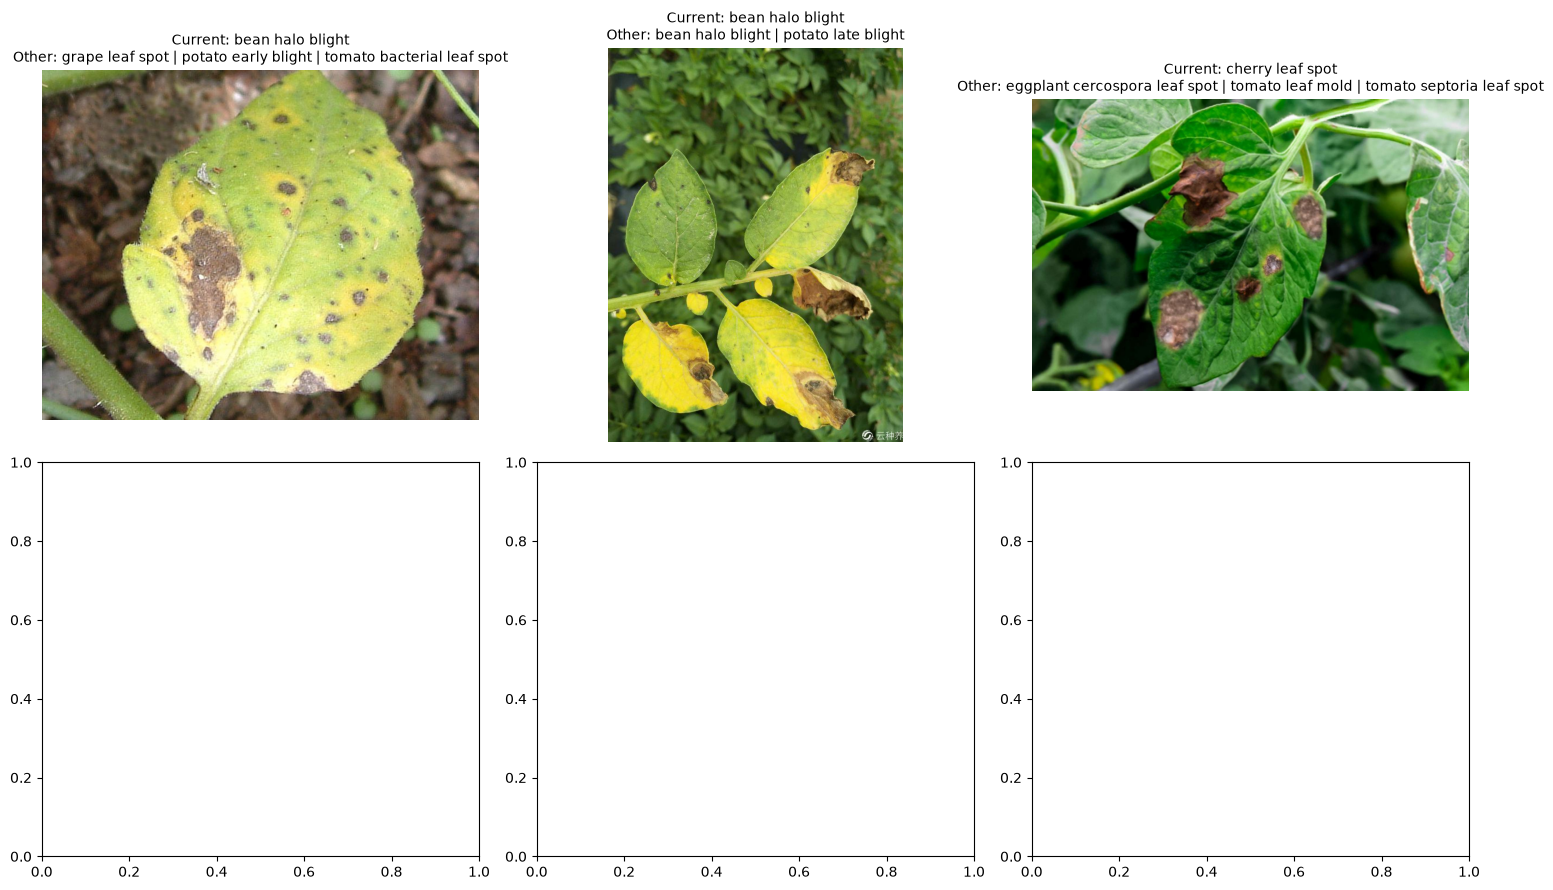

In [106]:
from PIL import Image
import matplotlib.pyplot as plt
import math

# Get one representative image for each unique hash
unique_special = special_review_df.drop_duplicates("Hash").copy()

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()

for ax, (_, row) in zip(axes, unique_special.iterrows()):
    image_path = DATASET_DIR / row["Path"]

    img = Image.open(image_path).convert("RGB")

    ax.imshow(img)
    ax.axis("off")

    ax.set_title(
        f"Current: {row['Class']}\n"
        f"Other: {row['Other_Classes']}",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [107]:
import shutil
from pathlib import Path

# Select the 6 special-review files
special_review_df = final_quarantine_df[
    final_quarantine_df["Decision"] == "SPECIAL_REVIEW"
].copy()

print("Special-review files to quarantine:", len(special_review_df))

# Quarantine directory
QUARANTINE_DIR = DATASET_DIR / "quarantine"
QUARANTINE_DIR.mkdir(parents=True, exist_ok=True)

moved_count = 0

for _, row in special_review_df.iterrows():

    source = DATASET_DIR / row["Path"]

    # Keep the PlantWild folder structure inside quarantine
    relative_to_plantwild = Path(row["Path"]).relative_to("plant wild")
    destination = QUARANTINE_DIR / relative_to_plantwild

    destination.parent.mkdir(parents=True, exist_ok=True)

    if source.exists():
        shutil.move(str(source), str(destination))
        moved_count += 1
        print("Moved:", row["Path"])
    else:
        print("NOT FOUND:", row["Path"])

print("\nMoved files:", moved_count)

Special-review files to quarantine: 6
Moved: plant wild\test\bean halo blight\google_0032.jpg
Moved: plant wild\test\tomato bacterial leaf spot\google_0055.jpg
Moved: plant wild\test\bean halo blight\24.jpg
Moved: plant wild\test\bean halo blight\26.jpg
Moved: plant wild\test\cherry leaf spot\google_0465.jpg
Moved: plant wild\test\eggplant cercospora leaf spot\google_0122.jpg

Moved files: 6


In [108]:
quarantine_files = [
    path
    for path in QUARANTINE_DIR.rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total quarantined images:", len(quarantine_files))

Total quarantined images: 136


In [109]:
plantwild_remaining = [
    path
    for path in (DATASET_DIR / "plant wild").rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Remaining PlantWild images:", len(plantwild_remaining))

Remaining PlantWild images: 18406


In [110]:
plantwild_dir = DATASET_DIR / "plant wild"

plantwild_files = [
    path
    for path in plantwild_dir.rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
]

plantwild_hashes = {}

for path in plantwild_files:
    try:
        with open(path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        plantwild_hashes.setdefault(file_hash, []).append(path)

    except Exception as e:
        print("Error:", path, e)

remaining_duplicate_groups = [
    paths
    for paths in plantwild_hashes.values()
    if len(paths) > 1
]

print("PlantWild images:", len(plantwild_files))
print("Unique hashes:", len(plantwild_hashes))
print("Remaining exact-duplicate groups:", len(remaining_duplicate_groups))

PlantWild images: 18406
Unique hashes: 18175
Remaining exact-duplicate groups: 218


In [111]:
cross_split_duplicates = []

for group in remaining_duplicate_groups:

    splits = set()

    for path in group:
        relative = path.relative_to(plantwild_dir)
        splits.add(relative.parts[0])

    if len(splits) > 1:
        cross_split_duplicates.append({
            "Splits": " | ".join(sorted(splits)),
            "Number_of_Files": len(group),
            "Paths": [
                str(path.relative_to(plantwild_dir))
                for path in group
            ]
        })

cross_split_df = pd.DataFrame(cross_split_duplicates)

print(
    "Remaining cross-split duplicate groups:",
    len(cross_split_duplicates)
)

display(cross_split_df.head(20))

Remaining cross-split duplicate groups: 26


,Splits,Number_of_Files,Paths
0,train | val,2,"[val\banana panama disease\addition (17).jpg, ..."
1,train | val,2,"[val\cabbage leaf\255.jpg, train\cabbage leaf\..."
2,train | val,2,"[val\corn northern leaf blight\add (6).jpg, tr..."
3,train | val,2,"[val\corn smut\174.jpg, train\corn smut\170.jpg]"
4,train | val,2,"[val\ginger leaf spot\105.jpg, train\ginger le..."
5,test | val,2,"[val\raspberry leaf\56.jpg, test\raspberry lea..."
6,train | val,2,"[val\tomato late blight\220.jpg, train\tomato ..."
7,test | train,2,"[train\apple leaf\34.jpg, test\apple leaf\28.jpg]"
8,test | train,2,"[train\apple rust\98.jpg, test\apple rust\286...."
9,test | train,2,"[train\banana panama disease\11.jpg, test\bana..."


In [112]:
# Identify remaining cross-split duplicate groups
cross_split_groups = []

for group in remaining_duplicate_groups:

    split_map = {}

    for path in group:
        relative = path.relative_to(plantwild_dir)
        split = relative.parts[0]

        split_map.setdefault(split, []).append(path)

    if len(split_map) > 1:
        cross_split_groups.append(split_map)

print("Cross-split duplicate groups:", len(cross_split_groups))

Cross-split duplicate groups: 26


In [113]:
cross_split_cleanup = []

for group in cross_split_groups:

    splits = set(group.keys())

    # Prefer TRAIN as the retained split
    if "train" in splits:
        keep_split = "train"

        for split, paths in group.items():
            if split != keep_split:
                for path in paths:
                    cross_split_cleanup.append({
                        "Path": str(path.relative_to(DATASET_DIR)),
                        "Split": split,
                        "Keep_Split": keep_split,
                        "Action": "QUARANTINE"
                    })

    # If there is no train copy, retain VAL and quarantine TEST
    elif "val" in splits and "test" in splits:
        keep_split = "val"

        for path in group["test"]:
            cross_split_cleanup.append({
                "Path": str(path.relative_to(DATASET_DIR)),
                "Split": "test",
                "Keep_Split": keep_split,
                "Action": "QUARANTINE"
            })

cross_split_cleanup_df = pd.DataFrame(cross_split_cleanup)

print("Files planned for quarantine:",
      len(cross_split_cleanup_df))

display(cross_split_cleanup_df.head(20))

Files planned for quarantine: 26


,Path,Split,Keep_Split,Action
0,plant wild\val\banana panama disease\addition ...,val,train,QUARANTINE
1,plant wild\val\cabbage leaf\255.jpg,val,train,QUARANTINE
2,plant wild\val\corn northern leaf blight\add (...,val,train,QUARANTINE
3,plant wild\val\corn smut\174.jpg,val,train,QUARANTINE
4,plant wild\val\ginger leaf spot\105.jpg,val,train,QUARANTINE
5,plant wild\test\raspberry leaf\58.jpg,test,val,QUARANTINE
6,plant wild\val\tomato late blight\220.jpg,val,train,QUARANTINE
7,plant wild\test\apple leaf\28.jpg,test,train,QUARANTINE
8,plant wild\test\apple rust\286.jpg,test,train,QUARANTINE
9,plant wild\test\banana panama disease\addition...,test,train,QUARANTINE


In [114]:
print(
    cross_split_cleanup_df["Split"]
    .value_counts()
)

print("\nTotal files:", len(cross_split_cleanup_df))

Split
test    20
val      6
Name: count, dtype: int64

Total files: 26


In [115]:
verification_rows = []

for _, row in cross_split_cleanup_df.iterrows():

    source = DATASET_DIR / row["Path"]

    # Find all identical copies
    matching_paths = []

    with open(source, "rb") as f:
        source_hash = hashlib.md5(f.read()).hexdigest()

    for path in plantwild_files:
        try:
            with open(path, "rb") as f:
                current_hash = hashlib.md5(f.read()).hexdigest()

            if current_hash == source_hash:
                matching_paths.append(path)

        except Exception:
            pass

    retained_copies = [
        path for path in matching_paths
        if path.relative_to(plantwild_dir).parts[0] == row["Keep_Split"]
    ]

    verification_rows.append({
        "Path": row["Path"],
        "Split": row["Split"],
        "Keep_Split": row["Keep_Split"],
        "Matching_Copies": len(matching_paths),
        "Retained_Copies": len(retained_copies),
        "Safe": len(retained_copies) > 0
    })

verification_df = pd.DataFrame(verification_rows)

display(verification_df)

,Path,Split,Keep_Split,Matching_Copies,Retained_Copies,Safe
0,plant wild\val\banana panama disease\addition ...,val,train,2,1,True
1,plant wild\val\cabbage leaf\255.jpg,val,train,2,1,True
2,plant wild\val\corn northern leaf blight\add (...,val,train,2,1,True
3,plant wild\val\corn smut\174.jpg,val,train,2,1,True
4,plant wild\val\ginger leaf spot\105.jpg,val,train,2,1,True
5,plant wild\test\raspberry leaf\58.jpg,test,val,2,1,True
6,plant wild\val\tomato late blight\220.jpg,val,train,2,1,True
7,plant wild\test\apple leaf\28.jpg,test,train,2,1,True
8,plant wild\test\apple rust\286.jpg,test,train,2,1,True
9,plant wild\test\banana panama disease\addition...,test,train,2,1,True


In [116]:
print("Total candidates:", len(verification_df))
print("Safe candidates:", verification_df["Safe"].sum())
print("Unsafe candidates:", (~verification_df["Safe"]).sum())

Total candidates: 26
Safe candidates: 26
Unsafe candidates: 0


In [117]:
# Move the 26 verified duplicate files to quarantine

safe_cleanup_df = cross_split_cleanup_df[
    verification_df["Safe"].values
].copy()

moved_count = 0

for _, row in safe_cleanup_df.iterrows():

    source = DATASET_DIR / row["Path"]

    relative_to_plantwild = Path(row["Path"]).relative_to("plant wild")
    destination = QUARANTINE_DIR / relative_to_plantwild

    destination.parent.mkdir(parents=True, exist_ok=True)

    if source.exists():
        shutil.move(str(source), str(destination))
        moved_count += 1
        print("Moved:", row["Path"])
    else:
        print("NOT FOUND:", row["Path"])

print("\nMoved files:", moved_count)

Moved: plant wild\val\banana panama disease\addition (17).jpg
Moved: plant wild\val\cabbage leaf\255.jpg
Moved: plant wild\val\corn northern leaf blight\add (6).jpg
Moved: plant wild\val\corn smut\174.jpg
Moved: plant wild\val\ginger leaf spot\105.jpg
Moved: plant wild\test\raspberry leaf\58.jpg
Moved: plant wild\val\tomato late blight\220.jpg
Moved: plant wild\test\apple leaf\28.jpg
Moved: plant wild\test\apple rust\286.jpg
Moved: plant wild\test\banana panama disease\addition (15).jpg
Moved: plant wild\test\basil leaf\121.jpg
Moved: plant wild\test\cabbage leaf\372.jpg
Moved: plant wild\test\cherry leaf\167.jpg
Moved: plant wild\test\citrus canker\305.jpg
Moved: plant wild\test\citrus canker\306.jpg
Moved: plant wild\test\corn gray leaf spot\30.jpg
Moved: plant wild\test\corn northern leaf blight\add (8).jpg
Moved: plant wild\test\garlic rust\180.jpg
Moved: plant wild\test\grape black rot\157.jpg
Moved: plant wild\test\grape downy mildew\102.jpg
Moved: plant wild\test\grape leaf spot

In [118]:
# Count remaining PlantWild images
plantwild_remaining = [
    path
    for path in (DATASET_DIR / "plant wild").rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
]

# Count all quarantined images
quarantine_files = [
    path
    for path in QUARANTINE_DIR.rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Remaining PlantWild images:", len(plantwild_remaining))
print("Total quarantined images:", len(quarantine_files))

Remaining PlantWild images: 18380
Total quarantined images: 162


In [119]:
# Rebuild the PlantWild file list after cleanup

plantwild_files_clean = [
    path
    for path in (DATASET_DIR / "plant wild").rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
]

plantwild_hashes_clean = {}

for path in plantwild_files_clean:
    try:
        with open(path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        plantwild_hashes_clean.setdefault(file_hash, []).append(path)

    except Exception as e:
        print("Error:", path, e)

remaining_duplicate_groups_clean = [
    paths
    for paths in plantwild_hashes_clean.values()
    if len(paths) > 1
]

cross_split_duplicates_clean = []

for group in remaining_duplicate_groups_clean:

    splits = set()

    for path in group:
        relative = path.relative_to(DATASET_DIR / "plant wild")
        splits.add(relative.parts[0])

    if len(splits) > 1:
        cross_split_duplicates_clean.append(group)

print("PlantWild images:", len(plantwild_files_clean))
print("Unique hashes:", len(plantwild_hashes_clean))
print("Remaining exact-duplicate groups:",
      len(remaining_duplicate_groups_clean))
print("Remaining cross-split duplicate groups:",
      len(cross_split_duplicates_clean))

PlantWild images: 18380
Unique hashes: 18175
Remaining exact-duplicate groups: 192
Remaining cross-split duplicate groups: 0


In [120]:
cross_class_remaining = []

for group in remaining_duplicate_groups_clean:

    class_names = set()

    for path in group:
        relative = path.relative_to(DATASET_DIR / "plant wild")

        # train/test/val/class/image
        if len(relative.parts) >= 4:
            class_names.add(relative.parts[1])

    if len(class_names) > 1:
        cross_class_remaining.append({
            "Classes": sorted(class_names),
            "Files": [
                str(path.relative_to(DATASET_DIR / "plant wild"))
                for path in group
            ]
        })

print(
    "Remaining exact-duplicate groups with different classes:",
    len(cross_class_remaining)
)

Remaining exact-duplicate groups with different classes: 0


In [121]:
plantwild_final_rows = []

for path in plantwild_files_clean:

    relative = path.relative_to(plantwild_dir)

    if len(relative.parts) < 3:
        continue

    split = relative.parts[0]
    class_name = relative.parts[1]

    plantwild_final_rows.append({
        "Split": split,
        "Class": class_name,
        "Path": str(relative)
    })

plantwild_final_df = pd.DataFrame(plantwild_final_rows)

print("Total valid PlantWild records:", len(plantwild_final_df))

display(
    plantwild_final_df
    .groupby("Split")
    .size()
    .reset_index(name="Image_Count")
)

Total valid PlantWild records: 18380


,Split,Image_Count
0,test,3567
1,train,13045
2,val,1768


In [122]:
class_count_by_split = (
    plantwild_final_df
    .groupby("Split")["Class"]
    .nunique()
    .reset_index(name="Number_of_Classes")
)

display(class_count_by_split)

,Split,Number_of_Classes
0,test,89
1,train,89
2,val,89


In [123]:
split_class_counts = pd.crosstab(
    plantwild_final_df["Class"],
    plantwild_final_df["Split"]
)

print("Classes missing from one or more splits:")

missing_classes = split_class_counts[
    (split_class_counts == 0).any(axis=1)
]

display(missing_classes)

Classes missing from one or more splits:


Split,test,train,val
Class,,,
